# Parameterization



In [17]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown

# Core simulation parameters
T = 50.0               # Total simulation time in seconds
dt = 0.01              # Time step size for Euler integration
speed = 0.5            # Rotation/speed term in the 2D linear system
leak = 0.0             # Analog state leak (damping)

# SCN/synapse dynamics
leak_r = 0.5           # Fast synapse decay rate (r)
lambda_slow = 0.5      # Slow filter rate from r to r_s
neurons = 100          # Number of spiking neurons in the population
voltage_leak = 0.5     # Membrane voltage leak term
seed = 0               # RNG seed for reproducible decoder initialization
decoder_scale = 10.0   # Decoder normalization scale (larger = smaller decoder vectors)

# Piecewise-constant input schedule: (start_time, end_time, value)
slow_segments = [(3, 10, 1.0), (16, 24, -0.8), (26, 32, 0.5), (40, 48, -0.5)]

# Baseline snapshot: keep this untouched so experiments can always be reset safely.
BASELINE_CONFIG = {
    'T': T,
    'dt': dt,
    'speed': speed,
    'leak': leak,
    'leak_r': leak_r,
    'lambda_slow': lambda_slow,
    'neurons': neurons,
    'voltage_leak': voltage_leak,
    'seed': seed,
    'decoder_scale': decoder_scale,
    'slow_segments': list(slow_segments),
}

ACTIVE_CONFIG = dict(BASELINE_CONFIG)

def apply_config(cfg):
    global T, dt, speed, leak, leak_r, lambda_slow, neurons, voltage_leak, seed, decoder_scale, slow_segments, ACTIVE_CONFIG
    T = float(cfg['T'])
    dt = float(cfg['dt'])
    speed = float(cfg['speed'])
    leak = float(cfg['leak'])
    leak_r = float(cfg['leak_r'])
    lambda_slow = float(cfg['lambda_slow'])
    neurons = int(cfg['neurons'])
    voltage_leak = float(cfg['voltage_leak'])
    seed = int(cfg['seed'])
    decoder_scale = float(cfg['decoder_scale'])
    slow_segments = list(cfg['slow_segments'])
    ACTIVE_CONFIG = dict(cfg)

def reset_to_baseline():
    apply_config(BASELINE_CONFIG)

display(Markdown(
    "**Baseline parameter snapshot saved.** "
    "Use `apply_config(...)` for experiments and `reset_to_baseline()` to restore these defaults."
))

**Baseline parameter snapshot saved.** Use `apply_config(...)` for experiments and `reset_to_baseline()` to restore these defaults.

# System Set-Up
$$
A = \begin{bmatrix} -\ell & \omega \\ -\omega & -\ell \end{bmatrix}, \quad
B = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad
x = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
$$

$$
\dot{x} = A x + B u(t)
$$

$$
\ell = leak, \omega = speed
$$

$$
u(t) \text{ is piecewise-constant from the defined input segments.}
$$


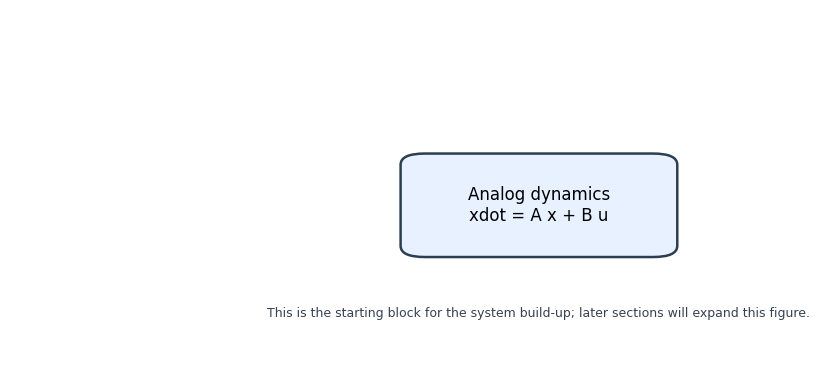

In [13]:


fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")


block = FancyBboxPatch(
    (0.50, 0.35),
    0.30,
    0.24,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#E8F1FF",
)
ax.add_patch(block)
ax.text(
    0.65,
    0.47,
    "Analog dynamics\nxdot = A x + B u",
    ha="center",
    va="center",
    fontsize=12,
)

ax.text(
    0.65,
    0.18,
    "This is the starting block for the system build-up; later sections will expand this figure.",
    ha="center",
    va="center",
    fontsize=9,
    color="#374151",
    wrap=True,
)


plt.show()

#### Build external input


In [14]:

def build_piecewise_input(times, segments):
    u = np.zeros_like(times)
    for t0, t1, val in segments:
        # Boolean mask selects samples in [t0, t1)
        mask = (times >= t0) & (times < t1)
        u[mask] = val
    return u


#### Simulate Initial System

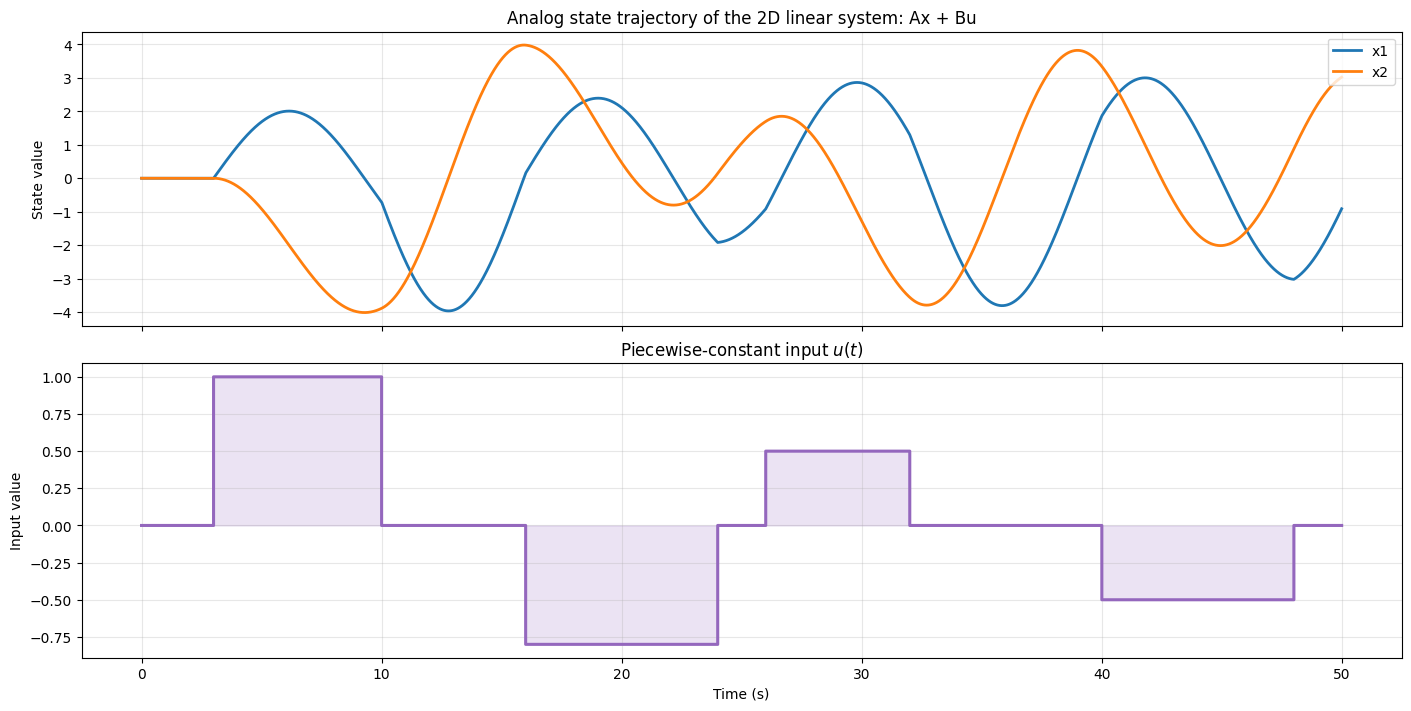

In [15]:

#x_dot = Ax + Bu
def simulate_linear_analog(T, dt, speed, leak, input_segments=None):
    steps = int(T / dt)
    t = np.arange(steps) * dt
    A = np.array([[-leak, speed],
                  [ -speed, -leak]], dtype=float)
    B = np.array([[1.0],
                  [0.0]], dtype=float)
    u = build_piecewise_input(t, input_segments or []) 
    x = np.zeros((steps, 2), dtype=float)

    for i in range(steps - 1):
        x_dot = A @ x[i] + B[:, 0] * u[i]
        x[i + 1] = x[i] + dt * x_dot
    return t, u, x, A, B




# Plotting the results
t, u, x, A, B = simulate_linear_analog(T, dt, speed, leak, slow_segments)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, constrained_layout=True)

axes[0].plot(t, x[:, 0], label='x1', color='tab:blue', linewidth=2.0)
axes[0].plot(t, x[:, 1], label='x2', color='tab:orange', linewidth=2.0)
axes[0].set_title('Analog state trajectory of the 2D linear system: Ax + Bu')
axes[0].set_ylabel('State value')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].step(t, u, where='post', color='tab:purple', linewidth=2.2)
axes[1].fill_between(t, 0.0, u, step='post', color='tab:purple', alpha=0.18)
axes[1].set_title('Piecewise-constant input $u(t)$')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Input value')
axes[1].grid(True, alpha=0.3)

plt.show()


In [16]:
# Remake: analog x (top) vs recurrent y (bottom), using thesis baseline parameters
import numpy as np
import matplotlib.pyplot as plt

# Ensure required functions exist
if "simulate_linear_analog" not in globals():
    raise RuntimeError("Run the system setup cells first (simulate_linear_analog is missing).")
if "simulate_y_replaced_system" not in globals():
    raise RuntimeError("Run the y-replaced system section first (simulate_y_replaced_system is missing).")

# Use baseline config so this figure is not affected by temporary local overrides (e.g., T=10 from LIF demo).
cfg = dict(BASELINE_CONFIG) if "BASELINE_CONFIG" in globals() else {
    "T": T,
    "dt": dt,
    "speed": speed,
    "leak": leak,
    "slow_segments": slow_segments,
    "neurons": neurons,
    "voltage_leak": voltage_leak,
    "seed": seed,
}

t_x, _, x_ref, _, _ = simulate_linear_analog(
    cfg["T"], cfg["dt"], cfg["speed"], cfg["leak"], cfg["slow_segments"]
)

t_y, _, _, y_recurrent, _, _ = simulate_y_replaced_system(
    cfg["T"], cfg["dt"], cfg["speed"], cfg["leak"], cfg["slow_segments"],
    neurons=cfg["neurons"], voltage_leak=cfg["voltage_leak"], seed=cfg["seed"],
)

# Common plotting interval
t_start = max(float(t_x[0]), float(t_y[0]))
t_end = min(float(t_x[-1]), float(t_y[-1]))
mask_x = (t_x >= t_start) & (t_x <= t_end)
mask_y = (t_y >= t_start) & (t_y <= t_end)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={"hspace": 0.35}
 )

# Top: analog state x
axes[0].plot(t_x[mask_x], x_ref[mask_x, 0], color="tab:blue", linewidth=1.3, label="x1 analog")
axes[0].plot(t_x[mask_x], x_ref[mask_x, 1], color="tab:orange", linewidth=1.3, label="x2 analog")
axes[0].set_title("Analog system response to slow input")
axes[0].set_ylabel("State x")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Bottom: recurrent substitute output y
axes[1].plot(t_y[mask_y], y_recurrent[mask_y, 0], color="#4CAF50", linewidth=1.2, label="y1 recurrent (slow synapse)")
axes[1].plot(t_y[mask_y], y_recurrent[mask_y, 1], color="#FF5252", linewidth=1.2, label="y2 recurrent (slow synapse)")
axes[1].set_title("Substitute output only")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("State y")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.show()

RuntimeError: Run the y-replaced system section first (simulate_y_replaced_system is missing).

## Initial System + SCN

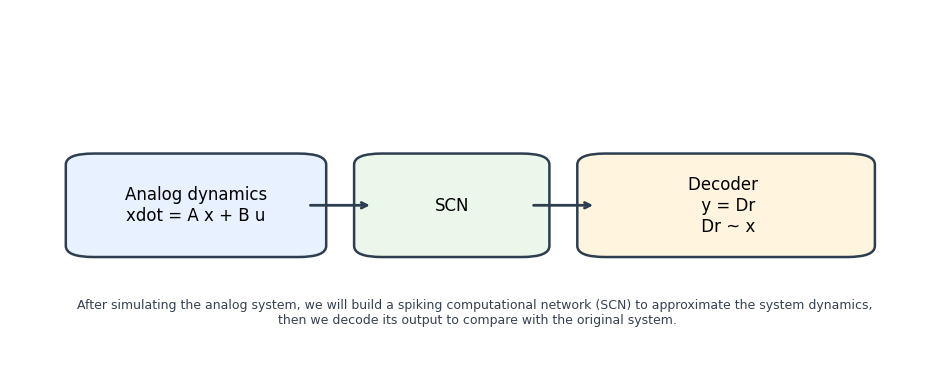

In [ ]:

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

block1 = FancyBboxPatch(
    (0.08, 0.35),
    0.24,
    0.24,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#E8F1FF",
)
ax.add_patch(block1)
ax.text(
    0.20,
    0.47,
    "Analog dynamics\nxdot = A x + B u",
    ha="center",
    va="center",
    fontsize=12,
)

block2 = FancyBboxPatch(
    (0.39, 0.35),
    0.17,
    0.24,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#EAF7EA",
)
ax.add_patch(block2)
ax.text(
    0.475,
    0.47,
    "SCN",
    ha="center",
    va="center",
    fontsize=12,
)

block3 = FancyBboxPatch(
    (0.63, 0.35),
    0.28,
    0.24,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#FFF4DD",
)
ax.add_patch(block3)
ax.text(
    0.77,
    0.47,
    "Decoder \n y = Dr\n Dr ~ x",
    ha="center",
    va="center",
    fontsize=12,
)

ax.annotate(
    "",
    xy=(0.39, 0.47),
    xytext=(0.32, 0.47),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)
ax.annotate(
    "",
    xy=(0.63, 0.47),
    xytext=(0.56, 0.47),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)

ax.text(
    0.50,
    0.18,
    "After simulating the analog system, we will build a spiking computational network (SCN) to approximate the system dynamics,\n then we decode its output to compare with the original system.",
    ha="center",
    va="center",
    fontsize=9,
    color="#374151",
    wrap=True,
)

plt.show()

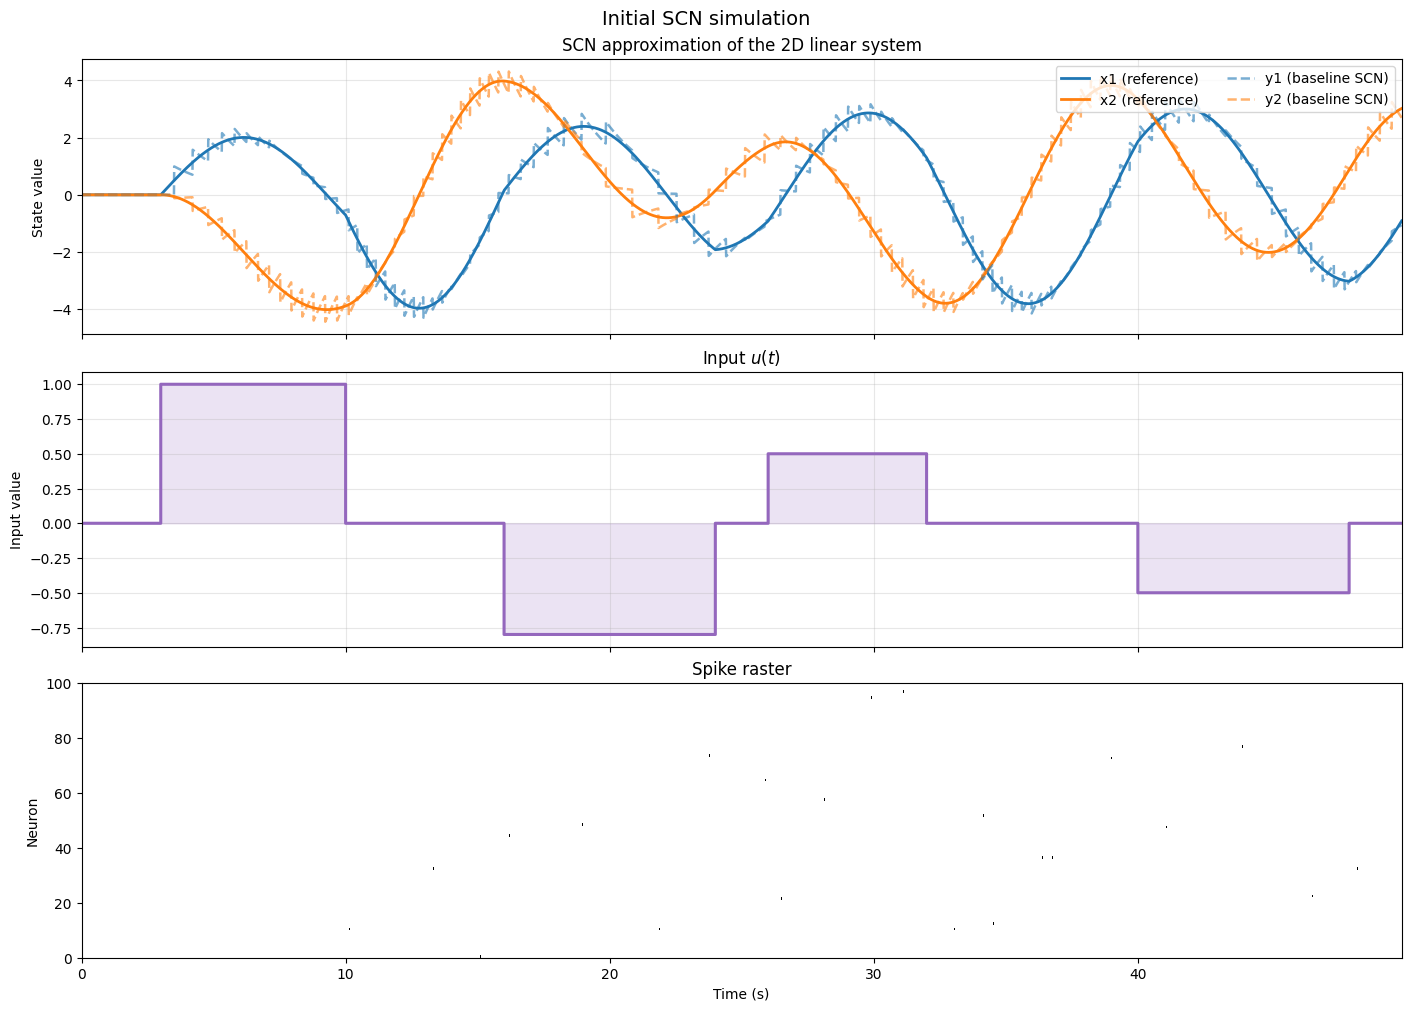

| Metric | Value |
|:---|---:|
| Total spikes | `100` |
| Active neurons | `52/100` (52.0%) |
| Silent neurons | `48/100` (48.0%) |
| Mean firing rate / neuron | `0.020 Hz` |
| Mean population rate | `0.020 Hz/neuron` |
| Peak population rate | `1.000 Hz/neuron` |
| Top-5 neuron spike share | `20.0%` |


In [20]:

# Function for simulating the SCN approximation of the 2D linear system
def simulate_scn_linear_system(T, dt, speed, leak, input_segments, neurons, voltage_leak, seed):
    rng = np.random.default_rng(seed)
    t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, input_segments)
    steps = len(t)

    D = rng.normal(0, 1, size=(2, neurons))
    D = D / np.linalg.norm(D, axis=0, keepdims=True)
    E = D.T
    v = np.zeros((steps, neurons))
    s = np.zeros((steps, neurons))
    r = np.zeros((steps, neurons))
    y = np.zeros((steps, 2))
    thresholds = 0.5 * np.diag(D.T @ D)
    leak_r = 0.5

    for i in range(steps - 1):
        x_dot = A @ x_ref[i] + B[:, 0] * u[i]
        recurrent_spike_feedback = E @ (D @ s[i])
        v_dot = -voltage_leak * v[i] + (E @ (voltage_leak * x_ref[i] + x_dot) - recurrent_spike_feedback)
        v[i + 1] = v[i] + dt * v_dot

        above_threshold = np.where(v[i + 1] > thresholds)[0]
        if len(above_threshold) > 0:
            winner_local = np.argmax(v[i + 1, above_threshold] - thresholds[above_threshold])
            winner = above_threshold[winner_local]
            s[i + 1, winner] = 1.0 / dt

        r[i + 1] = r[i] + dt * (-leak_r * r[i] + s[i + 1])
        y[i + 1] = D @ r[i + 1]

    return t, u, x_ref, y, s, r

# Initialise parameters and run the SCN simulation
t, u, x_ref, y, s, r = simulate_scn_linear_system(
    T, dt, speed, leak, slow_segments,
    neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

# --- Panel 1: Analog reference vs SCN output ---
axes[0].plot(t, x_ref[:, 0], label='x1 (reference)', color='tab:blue', linewidth=2.0)
axes[0].plot(t, x_ref[:, 1], label='x2 (reference)', color='tab:orange', linewidth=2.0)
axes[0].plot(t, y[:, 0], '--', label='y1 (baseline SCN)', color='tab:blue', linewidth=1.8, alpha=0.6)
axes[0].plot(t, y[:, 1], '--', label='y2 (baseline SCN)', color='tab:orange', linewidth=1.8, alpha=0.6)
axes[0].set_title('SCN approximation of the 2D linear system')
axes[0].set_ylabel('State value')
axes[0].legend(loc='upper right', ncol=2)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: Input schedule ---
axes[1].step(t, u, where='post', color='tab:purple', linewidth=2.2)
axes[1].fill_between(t, 0.0, u, step='post', color='tab:purple', alpha=0.18)
axes[1].set_title('Input $u(t)$')
axes[1].set_ylabel('Input value')
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Spike raster ---
spike_image = (s > 0).T.astype(float)
axes[2].imshow(
    spike_image,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t[0], t[-1], 0, s.shape[1]],
    cmap='Greys',
)
axes[2].set_title('Spike raster')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron')
axes[2].grid(False)

fig.suptitle('Initial SCN simulation', fontsize=14)
plt.show()

# --- Spike metrics ---
spike_events = s > 0
duration_s = t[-1] - t[0] + dt
total_spikes = int(np.count_nonzero(spike_events))
per_neuron_spikes = spike_events.sum(axis=0)
active_neurons = int(np.count_nonzero(per_neuron_spikes))
silent_neurons = s.shape[1] - active_neurons
mean_firing_rate_hz = total_spikes / (s.shape[1] * duration_s)
pop_rate_hz = spike_events.sum(axis=1) / (s.shape[1] * dt)
peak_pop_rate_hz = float(np.max(pop_rate_hz))
mean_pop_rate_hz = float(np.mean(pop_rate_hz))
top5_share = float(np.sum(np.sort(per_neuron_spikes)[-5:]) / max(1, total_spikes))

display(Markdown(
    f"| Metric | Value |\n|:---|---:|\n"
    f"| Total spikes | `{total_spikes}` |\n"
    f"| Active neurons | `{active_neurons}/{s.shape[1]}` ({100.0 * active_neurons / s.shape[1]:.1f}%) |\n"
    f"| Silent neurons | `{silent_neurons}/{s.shape[1]}` ({100.0 * silent_neurons / s.shape[1]:.1f}%) |\n"
    f"| Mean firing rate / neuron | `{mean_firing_rate_hz:.3f} Hz` |\n"
    f"| Mean population rate | `{mean_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Peak population rate | `{peak_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Top-5 neuron spike share | `{100.0 * top5_share:.1f}%` |\n"
))


## New System with Y-Replacement


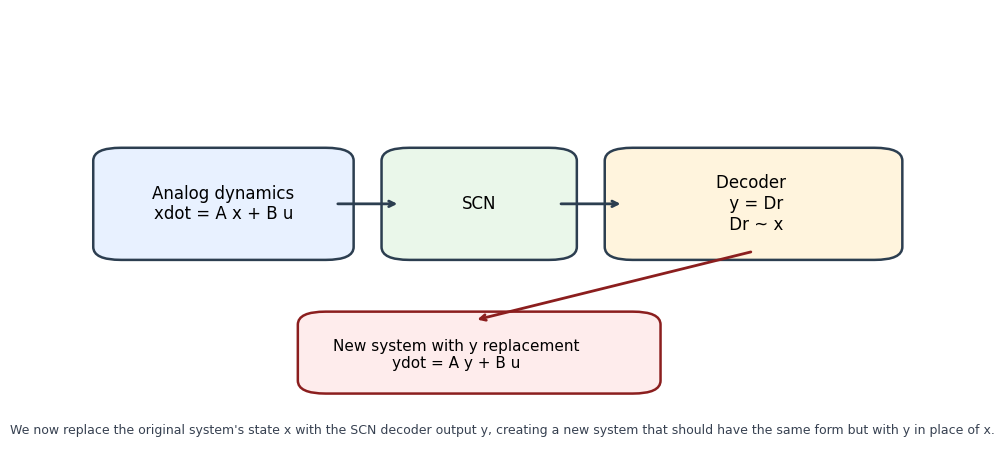

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

block1 = FancyBboxPatch(
    (0.08, 0.44),
    0.24,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#E8F1FF",
)
ax.add_patch(block1)
ax.text(
    0.20,
    0.55,
    "Analog dynamics\nxdot = A x + B u",
    ha="center",
    va="center",
    fontsize=12,
)

block2 = FancyBboxPatch(
    (0.39, 0.44),
    0.17,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#EAF7EA",
)
ax.add_patch(block2)
ax.text(
    0.475,
    0.55,
    "SCN",
    ha="center",
    va="center",
    fontsize=12,
)

block3 = FancyBboxPatch(
    (0.63, 0.44),
    0.28,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#FFF4DD",
)
ax.add_patch(block3)
ax.text(
    0.77,
    0.55,
    "Decoder \n y = Dr\n Dr ~ x",
    ha="center",
    va="center",
    fontsize=12,
)

block4 = FancyBboxPatch(
    (0.30, 0.13),
    0.35,
    0.15,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#8B1E1E",
    facecolor="#FEECEC",
)
ax.add_patch(block4)
ax.text(
    0.45,
    0.20,
    "New system with y replacement\nydot = A y + B u",
    ha="center",
    va="center",
    fontsize=11,
)

ax.annotate(
    "",
    xy=(0.39, 0.55),
    xytext=(0.32, 0.55),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)
ax.annotate(
    "",
    xy=(0.63, 0.55),
    xytext=(0.56, 0.55),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)
ax.annotate(
    "",
    xy=(0.47, 0.28),
    xytext=(0.77, 0.44),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#8B1E1E"),
)

ax.text(
    0.50,
    0.01,
    "We now replace the original system's state x with the SCN decoder output y, creating a new system that should have the same form but with y in place of x.",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#374151",
    wrap=True,
)

plt.show()

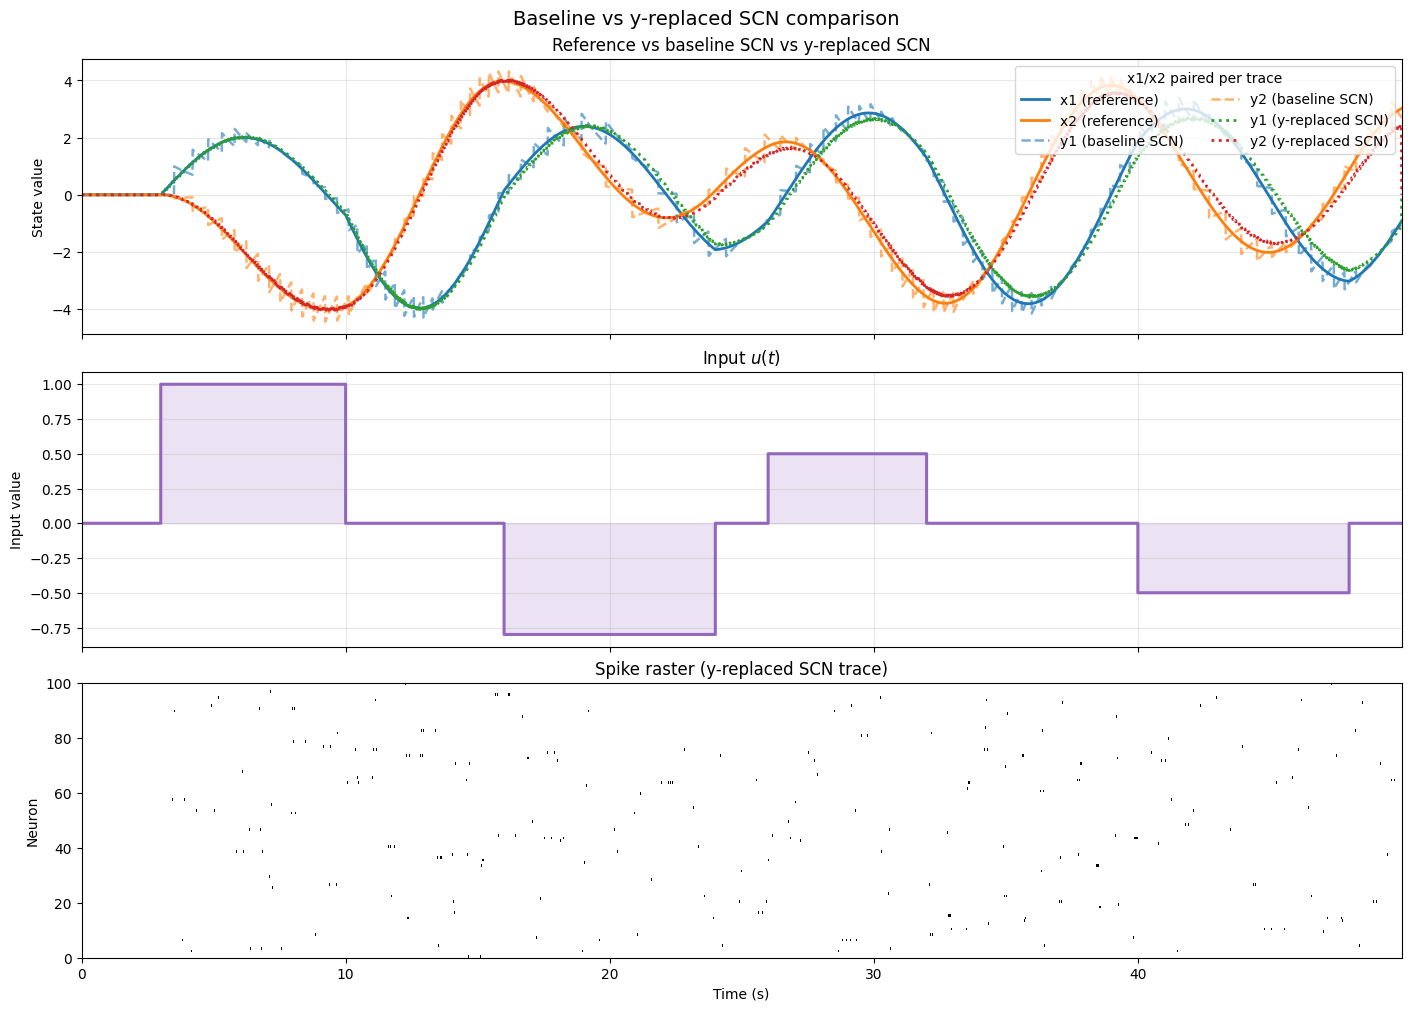

**Spike metrics (y-replaced SCN trace)**

| Metric | Value |
|:---|---:|
| Total spikes | `952` |
| Active neurons | `96/100` (96.0%) |
| Silent neurons | `4/100` (4.0%) |
| Mean firing rate / neuron | `0.190 Hz` |
| Mean population rate | `0.190 Hz/neuron` |
| Peak population rate | `1.000 Hz/neuron` |
| Top-5 neuron spike share | `12.4%` |


In [ ]:

def simulate_y_replaced_system(T, dt, speed, leak, input_segments, neurons, voltage_leak, seed):
    rng = np.random.default_rng(seed)
    t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, input_segments)
    steps = len(t)

    D = rng.normal(0, 1, size=(2, neurons))
    D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale
    E = D.T
    v = np.zeros((steps, neurons))
    s = np.zeros((steps, neurons))
    r = np.zeros((steps, neurons))
    y = np.zeros((steps, 2))
    thresholds = 0.5 * np.diag(D.T @ D)
    

    for i in range(steps - 1):
        # Decoded state from current filtered rates.
        y_i = D @ r[i]
        y[i] = y_i

        # Substitution dynamics: y_dot = A y + B u  (the red block from WB1 Section 8).
        y_dot = A @ y_i + B[:, 0] * u[i]

        # D^T (lambda_v * y + y_dot) - D^T D s
        recurrent = D.T @ (D @ s[i])
        v_dot = -voltage_leak * v[i] + (D.T @ (voltage_leak * y_i + y_dot) - recurrent)
        v[i + 1] = v[i] + dt * v_dot

        # Winner-take-all spike (at most one neuron per timestep).
        above = np.where(v[i + 1] > thresholds)[0]
        if len(above) > 0:
            winner = above[np.argmax(v[i + 1, above] - thresholds[above])]
            s[i + 1, winner] = 1.0 / dt

        r[i + 1] = r[i] + dt * (-leak_r * r[i] + s[i])

    return t, u, x_ref, y, s, r

# Initialise parameters and run the baseline SCN simulation
t_scn, u_scn, x_ref_scn, y_scn, s_scn, r_scn = simulate_scn_linear_system(
    T, dt, speed, leak, slow_segments,
    neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

# Run the y-replaced recurrent simulation
t_yrep, u_yrep, x_ref_yrep, y_yrep, s_yrep, r_yrep = simulate_y_replaced_system(
    T, dt, speed, leak, slow_segments, neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

# --- Panel 1: Analog reference vs SCN outputs ---
axes[0].plot()
ref_x1, = axes[0].plot(t_scn, x_ref_scn[:, 0], label='x1 (reference)', color='tab:blue', linewidth=2.0)
ref_x2, = axes[0].plot(t_scn, x_ref_scn[:, 1], label='x2 (reference)', color='tab:orange', linewidth=2.0)
scn_x1, = axes[0].plot(t_scn, y_scn[:, 0], '--', label='y1 (baseline SCN)', color='tab:blue', linewidth=1.8, alpha=0.6)
scn_x2, = axes[0].plot(t_scn, y_scn[:, 1], '--', label='y2 (baseline SCN)', color='tab:orange', linewidth=1.8, alpha=0.6)
yrep_x1, = axes[0].plot(t_yrep, y_yrep[:, 0], ':', label='y1 (y-replaced SCN)', color='tab:green', linewidth=2.0)
yrep_x2, = axes[0].plot(t_yrep, y_yrep[:, 1], ':', label='y2 (y-replaced SCN)', color='tab:red', linewidth=2.0)
axes[0].set_title('Reference vs baseline SCN vs y-replaced SCN')
axes[0].set_ylabel('State value')
axes[0].legend(
    handles=[ref_x1, ref_x2, scn_x1, scn_x2, yrep_x1, yrep_x2],
    loc='upper right',
    ncol=2,
    title='x1/x2 paired per trace',
)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: Input schedule ---
axes[1].step(t_scn, u_scn, where='post', color='tab:purple', linewidth=2.2)
axes[1].fill_between(t_scn, 0.0, u_scn, step='post', color='tab:purple', alpha=0.18)
axes[1].set_title('Input $u(t)$')
axes[1].set_ylabel('Input value')
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Spike raster (y-replaced SCN trace) ---
spike_image = (s_yrep > 0).T.astype(float)
axes[2].imshow(
    spike_image,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t_yrep[0], t_yrep[-1], 0, s_yrep.shape[1]],
    cmap='Greys',
)
axes[2].set_title('Spike raster (y-replaced SCN trace)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron')
axes[2].grid(False)

fig.suptitle('Baseline vs y-replaced SCN comparison', fontsize=14)
plt.show()

# --- Spike metrics for y-replaced SCN trace ---
spike_events = s_yrep > 0
duration_s = t_yrep[-1] - t_yrep[0] + dt
total_spikes = int(np.count_nonzero(spike_events))
per_neuron_spikes = spike_events.sum(axis=0)
active_neurons = int(np.count_nonzero(per_neuron_spikes))
silent_neurons = s_yrep.shape[1] - active_neurons
mean_firing_rate_hz = total_spikes / (s_yrep.shape[1] * duration_s)
pop_rate_hz = spike_events.sum(axis=1) / (s_yrep.shape[1] * dt)
peak_pop_rate_hz = float(np.max(pop_rate_hz))
mean_pop_rate_hz = float(np.mean(pop_rate_hz))
top5_share = float(np.sum(np.sort(per_neuron_spikes)[-5:]) / max(1, total_spikes))

display(Markdown(
    '**Spike metrics (y-replaced SCN trace)**\n\n'
    f"| Metric | Value |\n|:---|---:|\n"
    f"| Total spikes | `{total_spikes}` |\n"
    f"| Active neurons | `{active_neurons}/{s_yrep.shape[1]}` ({100.0 * active_neurons / s_yrep.shape[1]:.1f}%) |\n"
    f"| Silent neurons | `{silent_neurons}/{s_yrep.shape[1]}` ({100.0 * silent_neurons / s_yrep.shape[1]:.1f}%) |\n"
    f"| Mean firing rate / neuron | `{mean_firing_rate_hz:.3f} Hz` |\n"
    f"| Mean population rate | `{mean_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Peak population rate | `{peak_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Top-5 neuron spike share | `{100.0 * top5_share:.1f}%` |\n"
))


#### Zoomed In


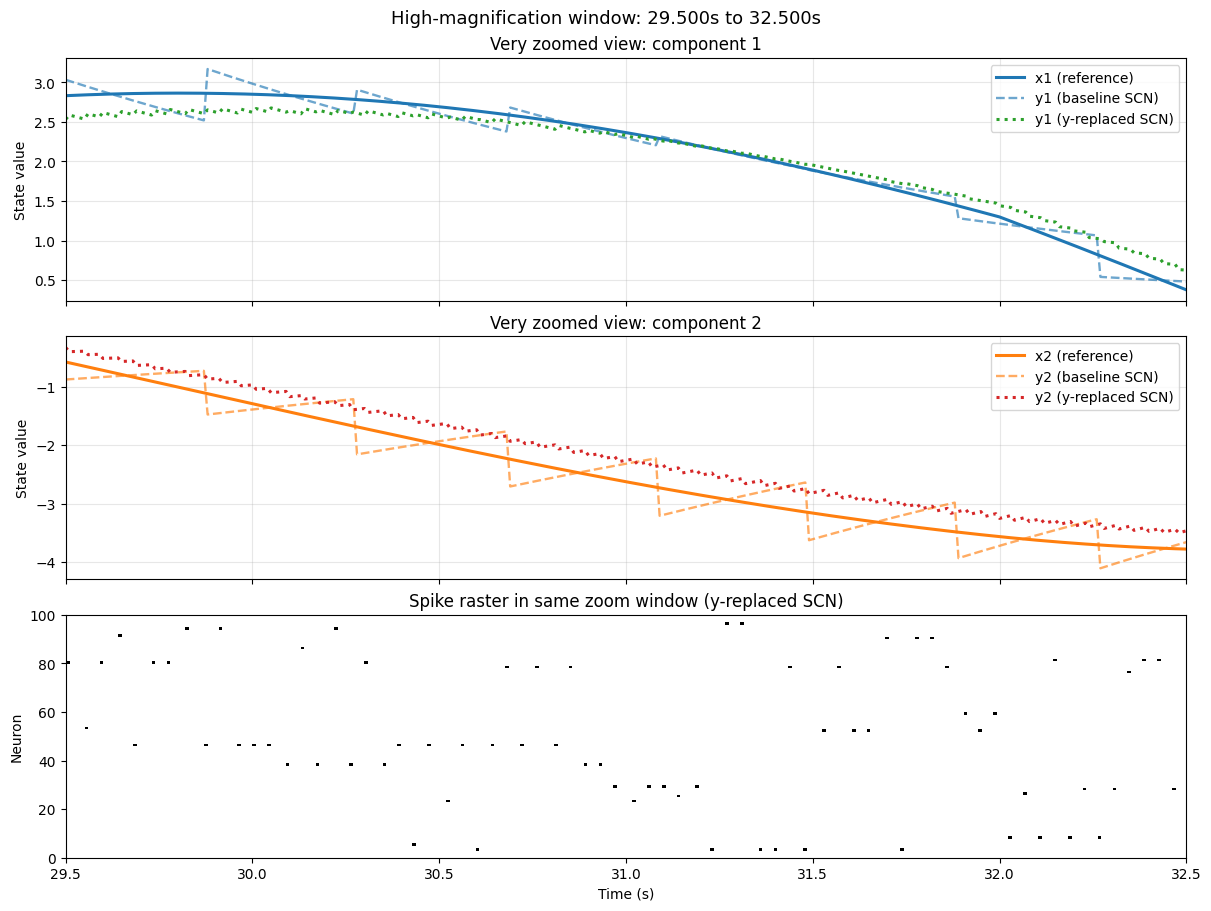

In [ ]:

# Zoomed-in trace view with vertically aligned panels
zoom_center = 31.0   # seconds
zoom_width = 3.0     # seconds

t0 = max(t_scn[0], zoom_center - zoom_width / 2)
t1 = min(t_scn[-1], zoom_center + zoom_width / 2)
mask_scn = (t_scn >= t0) & (t_scn <= t1)
mask_yrep = (t_yrep >= t0) & (t_yrep <= t1)

# Bottom raster uses y-replaced SCN spikes in the same zoom window
idx_yrep = np.where(mask_yrep)[0]
s_zoom = s_yrep[idx_yrep]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

# State/component 1
axes[0].plot(t_scn[mask_scn], x_ref_scn[mask_scn, 0], color='tab:blue', linewidth=2.2, label='x1 (reference)')
axes[0].plot(t_scn[mask_scn], y_scn[mask_scn, 0], '--', color='tab:blue', alpha=0.65, linewidth=1.7, label='y1 (baseline SCN)')
axes[0].plot(t_yrep[mask_yrep], y_yrep[mask_yrep, 0], ':', color='tab:green', linewidth=2.2, label='y1 (y-replaced SCN)')
axes[0].set_title('Very zoomed view: component 1')
axes[0].set_ylabel('State value')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

# State/component 2
axes[1].plot(t_scn[mask_scn], x_ref_scn[mask_scn, 1], color='tab:orange', linewidth=2.2, label='x2 (reference)')
axes[1].plot(t_scn[mask_scn], y_scn[mask_scn, 1], '--', color='tab:orange', alpha=0.65, linewidth=1.7, label='y2 (baseline SCN)')
axes[1].plot(t_yrep[mask_yrep], y_yrep[mask_yrep, 1], ':', color='tab:red', linewidth=2.2, label='y2 (y-replaced SCN)')
axes[1].set_title('Very zoomed view: component 2')
axes[1].set_ylabel('State value')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

# Spike raster underneath (y-replaced SCN trace)
spike_image_zoom = (s_zoom > 0).T.astype(float)
axes[2].imshow(
    spike_image_zoom,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t0, t1, 0, s_yrep.shape[1]],
    cmap='Greys',
)
axes[2].set_title('Spike raster in same zoom window (y-replaced SCN)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron')
axes[2].grid(False)

fig.suptitle(f'High-magnification window: {t0:.3f}s to {t1:.3f}s', fontsize=13)
plt.show()

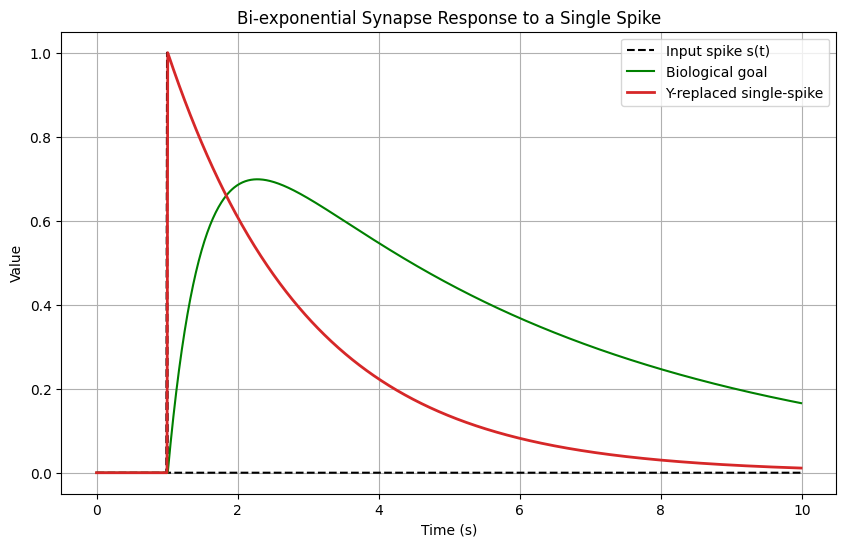

In [ ]:
plt.figure(figsize=(10, 6))
t_goal, s_goal, r_rise, r_decay, r_bi, r_s_model = simulate_bi_exponential_goal(
    total_time=10.0, dt=0.01, spike_at_time=1.0,
    leak_rise=2.0, leak_decay=0.2, leak_r_model=0.8, leak_r_s_model=0.2
)

# Single-spike response using the same fast synapse update as the y-replaced section.
r_yrep_single = np.zeros_like(t_goal)
for i in range(len(t_goal) - 1):
    r_yrep_single[i + 1] = r_yrep_single[i] + dt * (-leak_r * r_yrep_single[i] + s_goal[i] / dt)

plt.plot(t_goal, s_goal, label='Input spike s(t)', color='black', linestyle='--')
plt.plot(t_goal, r_bi, label='Biological goal', color='green')
plt.plot(t_goal, r_yrep_single, label='Y-replaced single-spike', color='tab:red', linewidth=2.0)
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Bi-exponential Synapse Response to a Single Spike')
plt.legend()
plt.grid()
plt.show()

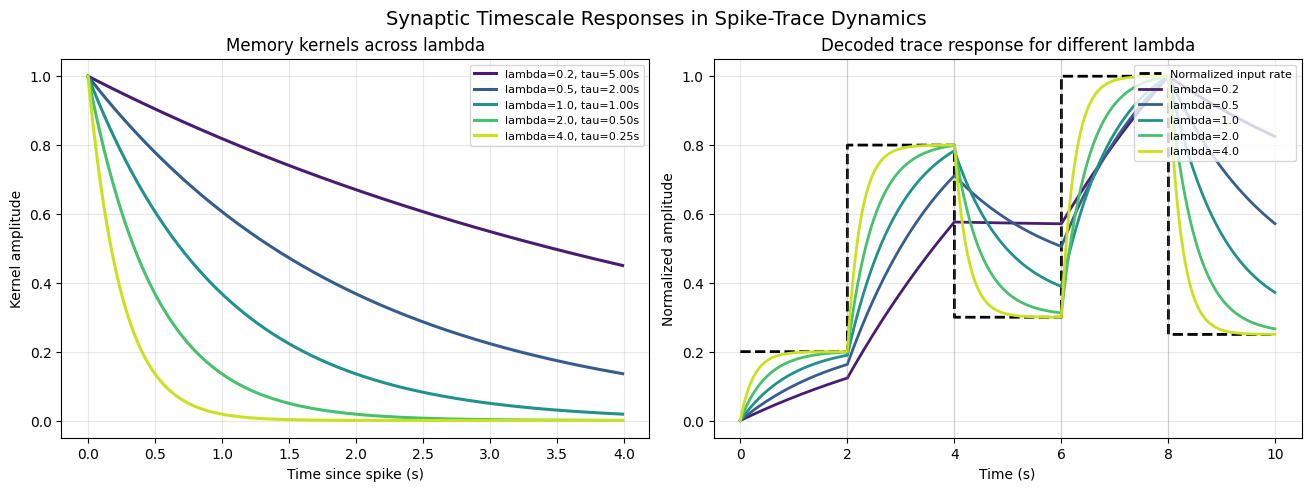

In [21]:
# Lambda response figure: memory kernels + filtered traces (trade-off summary removed)

import numpy as np

import matplotlib.pyplot as plt



dt_local = float(dt) if "dt" in globals() else 0.01

t_end = 10.0

t_syn = np.arange(0.0, t_end, dt_local)



# Deterministic step-like spike-rate drive (cleaner than stochastic spikes for interpretation)

rate_hz = np.piecewise(

    t_syn,

    [t_syn < 2.0, (t_syn >= 2.0) & (t_syn < 4.0), (t_syn >= 4.0) & (t_syn < 6.0), (t_syn >= 6.0) & (t_syn < 8.0), t_syn >= 8.0],

    [4.0, 16.0, 6.0, 20.0, 5.0],

)



# Use expected spike drive for clearer response curves

s_drive = rate_hz



# Lambda sweep (small lambda => longer memory, larger delay)

lambda_values = np.array([0.2, 0.5, 1.0, 2.0, 4.0], dtype=float)

colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(lambda_values)))

taus = 1.0 / lambda_values



# Simulate filtered traces

traces = []

for lam in lambda_values:

    r_trace = np.zeros_like(t_syn)

    for i in range(1, len(t_syn)):

        r_trace[i] = r_trace[i - 1] + dt_local * (-lam * r_trace[i - 1] + s_drive[i - 1])

    traces.append(r_trace)



traces = np.array(traces)



fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)



# Panel A: memory kernels for all lambda values

axA = axes[0]

t_kernel = np.arange(0.0, 4.0, dt_local)

for lam, tau, c in zip(lambda_values, taus, colors):

    kernel = np.exp(-lam * t_kernel)

    axA.plot(t_kernel, kernel, color=c, linewidth=2.2, label=f"lambda={lam:.1f}, tau={tau:.2f}s")

axA.set_title("Memory kernels across lambda")

axA.set_xlabel("Time since spike (s)")

axA.set_ylabel("Kernel amplitude")

axA.grid(True, alpha=0.3)

axA.legend(loc="upper right", fontsize=8)



# Panel B: rate input and filtered traces

axB = axes[1]

axB.step(t_syn, rate_hz / np.max(rate_hz), where="post", color="black", linestyle="--", linewidth=2.0, label="Normalized input rate")

for lam, c, r_trace in zip(lambda_values, colors, traces):

    r_norm = r_trace / (np.max(r_trace) + 1e-12)

    axB.plot(t_syn, r_norm, color=c, linewidth=2.0, label=f"lambda={lam:.1f}")



for t_change in [2.0, 4.0, 6.0, 8.0]:

    axB.axvline(t_change, color="gray", linewidth=0.9, alpha=0.25)



axB.set_title("Decoded trace response for different lambda")

axB.set_xlabel("Time (s)")

axB.set_ylabel("Normalized amplitude")

axB.grid(True, alpha=0.3)

axB.legend(loc="upper right", fontsize=8, ncol=1)



fig.suptitle("Synaptic Timescale Responses in Spike-Trace Dynamics", fontsize=14)

plt.show()

## Y-Replaced System with Slow Filtering r_s


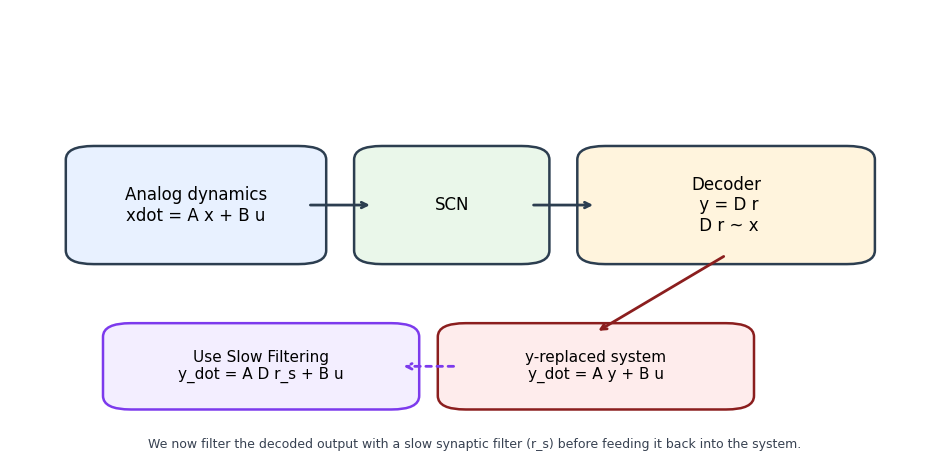

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5.9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

block1 = FancyBboxPatch(
    (0.08, 0.46),
    0.24,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#E8F1FF",
)
ax.add_patch(block1)
ax.text(
    0.20,
    0.57,
    "Analog dynamics\nxdot = A x + B u",
    ha="center",
    va="center",
    fontsize=12,
)

block2 = FancyBboxPatch(
    (0.39, 0.46),
    0.17,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#EAF7EA",
)
ax.add_patch(block2)
ax.text(
    0.475,
    0.57,
    "SCN",
    ha="center",
    va="center",
    fontsize=12,
)

block3 = FancyBboxPatch(
    (0.63, 0.46),
    0.28,
    0.22,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#2c3e50",
    facecolor="#FFF4DD",
)
ax.add_patch(block3)
ax.text(
    0.77,
    0.57,
    "Decoder\n y = D r\n D r ~ x",
    ha="center",
    va="center",
    fontsize=12,
)

block4 = FancyBboxPatch(
    (0.48, 0.14),
    0.30,
    0.15,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#8B1E1E",
    facecolor="#FEECEC",
)
ax.add_patch(block4)
ax.text(
    0.63,
    0.215,
    "y-replaced system\ny_dot = A y + B u",
    ha="center",
    va="center",
    fontsize=11,
)

block5 = FancyBboxPatch(
    (0.12, 0.14),
    0.30,
    0.15,
    boxstyle="round,pad=0.02,rounding_size=0.03",
    linewidth=1.8,
    edgecolor="#7C3AED",
    facecolor="#F3EEFF",
)
ax.add_patch(block5)
ax.text(
    0.27,
    0.215,
    "Use Slow Filtering\ny_dot = A D r_s + B u",
    ha="center",
    va="center",
    fontsize=11,
)

ax.annotate(
    "",
    xy=(0.39, 0.57),
    xytext=(0.32, 0.57),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)
ax.annotate(
    "",
    xy=(0.63, 0.57),
    xytext=(0.56, 0.57),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#2c3e50"),
)
ax.annotate(
    "",
    xy=(0.63, 0.29),
    xytext=(0.77, 0.46),
    arrowprops=dict(arrowstyle="->", lw=2.0, color="#8B1E1E"),
)
ax.annotate(
    "",
    xy=(0.42, 0.215),
    xytext=(0.48, 0.215),
    arrowprops=dict(arrowstyle="->", lw=2.0, linestyle=(0, (2, 2)), color="#7C3AED"),
)

ax.text(
    0.45,
    0.25,
    "",
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#6D28D9",
)

ax.text(
    0.50,
    0.03,
    "We now filter the decoded output with a slow synaptic filter (r_s) before feeding it back into the system.",
    ha="center",
    va="bottom",
    fontsize=9,
    color="#374151",
    wrap=True,
)

plt.show()

$$
r[i+1] = r[i] + dt\,(-leak_r\,r[i] + s[i])
$$

$$
r_s[i+1] = r_s[i] + dt\,\lambda_{slow}\,(-r_s[i] + r[i])
$$

Then the decoded output is

$$
y[i] = D\,r_s[i]
$$

`r` is the fast exponential spike trace, `r_s` is the slower low-pass trace, and `y` is the filtered decoded signal used for comparison with the reference state.

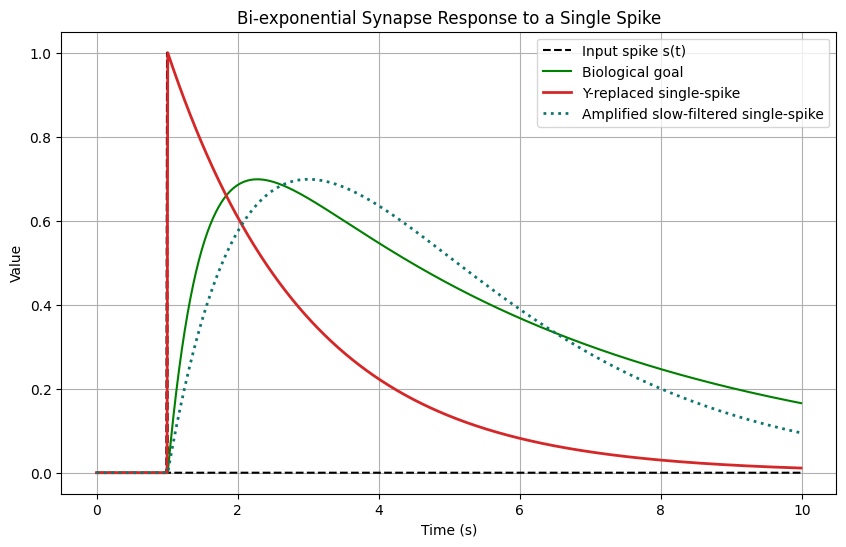

In [ ]:

plt.figure(figsize=(10, 6))
t_goal, s_goal, r_rise, r_decay, r_bi, r_s_model = simulate_bi_exponential_goal(
    total_time=10.0, dt=0.01, spike_at_time=1.0,
    leak_rise=2.0, leak_decay=0.2, leak_r_model=0.8, leak_r_s_model=0.2
)

# Single-spike response using the same fast synapse update as the y-replaced section.
r_yrep_single = np.zeros_like(t_goal)
r_slow_filtered_single = np.zeros_like(t_goal)
for i in range(len(t_goal) - 1):
    r_yrep_single[i + 1] = r_yrep_single[i] + dt * (-leak_r * r_yrep_single[i] + s_goal[i] / dt)
    r_slow_filtered_single[i + 1] = r_slow_filtered_single[i] + dt * (lambda_slow * (-r_slow_filtered_single[i] + r_yrep_single[i]))

slow_filtered_peak = np.max(r_slow_filtered_single)
biological_peak = np.max(r_bi)
slow_filtered_amplified = r_slow_filtered_single.copy()
if slow_filtered_peak > 0:
    slow_filtered_amplified *= biological_peak / slow_filtered_peak

plt.plot(t_goal, s_goal, label='Input spike s(t)', color='black', linestyle='--')
plt.plot(t_goal, r_bi, label='Biological goal', color='green')
plt.plot(t_goal, r_yrep_single, label='Y-replaced single-spike', color='tab:red', linewidth=2.0)
plt.plot(
    t_goal,
    slow_filtered_amplified,
    label='Amplified slow-filtered single-spike',
    color='#0F766E',
    linewidth=2.0,
    linestyle=':',
)
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Bi-exponential Synapse Response to a Single Spike')
plt.legend()
plt.grid()
plt.show()

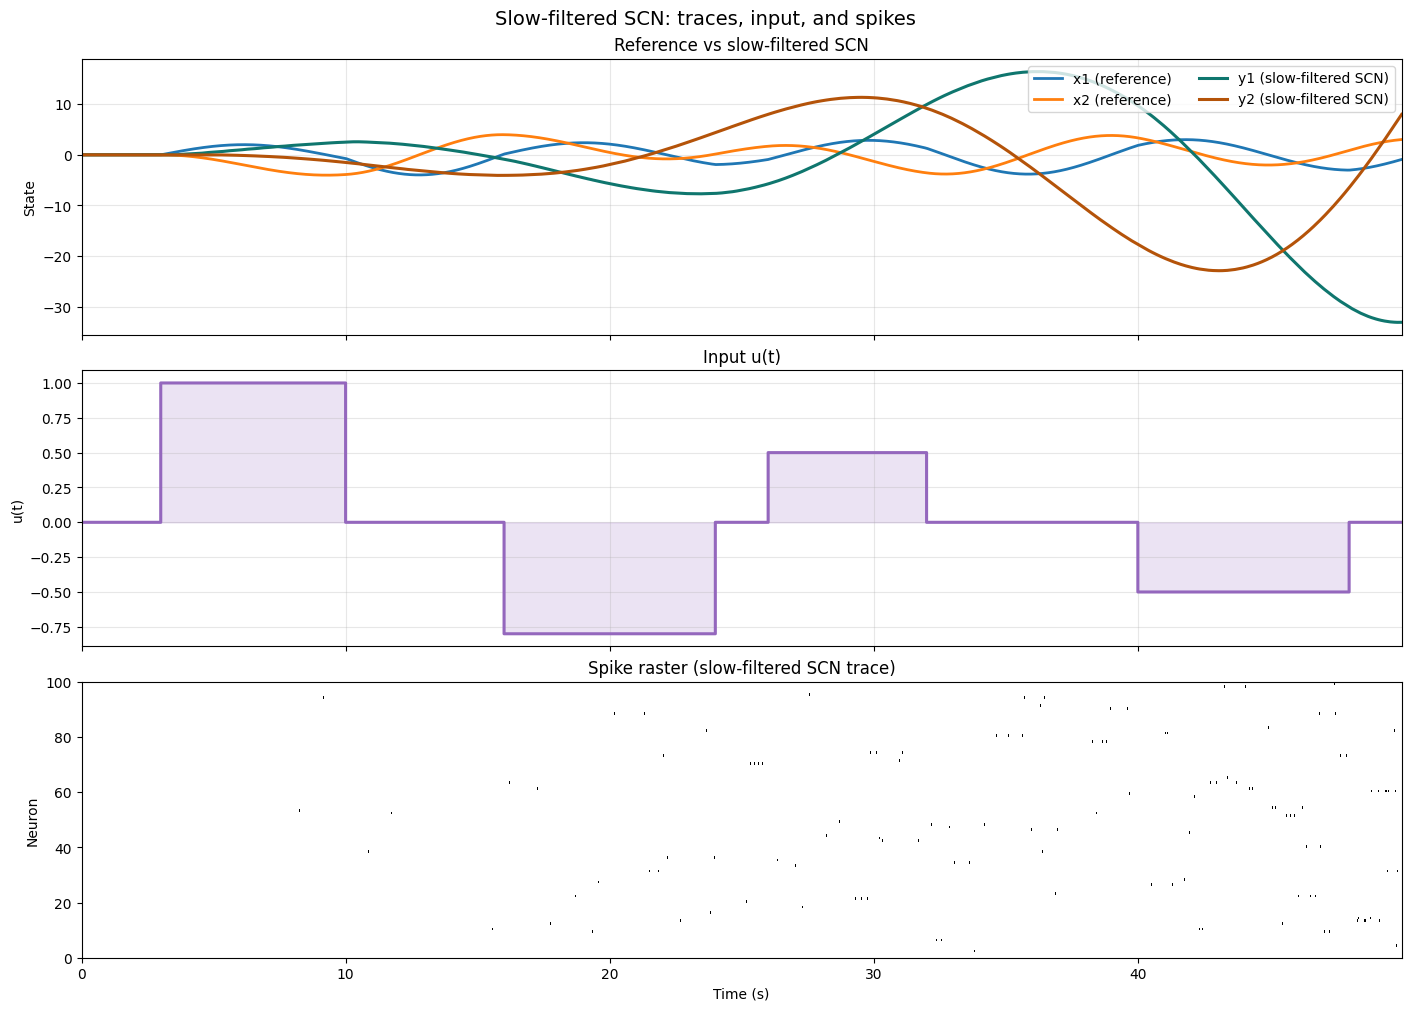

**Spike metrics (slow-filtered SCN trace)**

| Metric | Value |
|:---|---:|
| Total spikes | `416` |
| Active neurons | `89/100` (89.0%) |
| Silent neurons | `11/100` (11.0%) |
| Mean firing rate / neuron | `0.083 Hz` |
| Mean population rate | `0.083 Hz/neuron` |
| Peak population rate | `1.000 Hz/neuron` |
| Top-5 neuron spike share | `17.1%` |


In [ ]:


def simulate_scn_linear_system_local(T, dt, speed, leak, input_segments, neurons=100, voltage_leak=0.5, seed=1):
    rng = np.random.default_rng(seed)
    t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, input_segments)
    steps = len(t)

    D = rng.normal(0, 1, size=(2, neurons))
    D = (D / np.linalg.norm(D, axis=0, keepdims=True)) 
    E = D.T
    v = np.zeros((steps, neurons))
    s = np.zeros((steps, neurons))
    r = np.zeros((steps, neurons))
    r_s = np.zeros((steps, neurons))
    y = np.zeros((steps, 2))
    thresholds = 0.5 * np.diag(D.T @ D)
    

    
    for i in range(steps - 1):
        y_dot = A @ y[i] + B[:, 0] * u[i]
        recurrent_spike_feedback = E @ (D @ s[i])

        v_dot = -voltage_leak * v[i] + (E @ (voltage_leak * y[i] + y_dot) - recurrent_spike_feedback)
        v[i + 1] = v[i] + dt * v_dot

        above_threshold = np.where(v[i + 1] > thresholds)[0]
        if len(above_threshold) > 0:
            winner_local = np.argmax(v[i + 1, above_threshold] - thresholds[above_threshold])
            winner = above_threshold[winner_local]
            s[i + 1, winner] = 1.0 / dt

        r[i + 1] = r[i] + dt * (-leak_r * r[i] + s[i + 1])
        r_s[i + 1] = r_s[i] + dt * (lambda_slow * (-r_s[i] + r[i]))
        y[i + 1] = D @ r_s[i + 1]

    return t, u, x_ref, y, s, r_s

# Initialise slow-filtered simulation
t, u, x_ref, y, s, r_s = simulate_scn_linear_system_local(
    T, dt, speed, leak, slow_segments,
    neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

# --- Panel 1: Reference vs slow-filtered decoded traces ---
ref_x1, = axes[0].plot(t, x_ref[:, 0], label='x1 (reference)', color='tab:blue', linewidth=2.0)
ref_x2, = axes[0].plot(t, x_ref[:, 1], label='x2 (reference)', color='tab:orange', linewidth=2.0)
slow_x1, = axes[0].plot(t, y[:, 0], label='y1 (slow-filtered SCN)', color='#0F766E', linewidth=2.2)
slow_x2, = axes[0].plot(t, y[:, 1], label='y2 (slow-filtered SCN)', color='#B45309', linewidth=2.2)
axes[0].set_title('Reference vs slow-filtered SCN')
axes[0].set_ylabel('State')
axes[0].legend(
    handles=[ref_x1, ref_x2, slow_x1, slow_x2],
    loc='upper right',
    ncol=2,
)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: Input schedule ---
axes[1].step(t, u, where='post', color='tab:purple', linewidth=2.2)
axes[1].plot(t, u, color='tab:purple', linewidth=1.0, alpha=0.9)
axes[1].fill_between(t, 0.0, u, step='post', color='tab:purple', alpha=0.18)
axes[1].set_title('Input u(t)')
axes[1].set_ylabel('u(t)')
axes[1].grid(True, alpha=0.3)

# --- Panel 3: Spike raster for the slow-filtered trace ---
spike_image = (s > 0).T.astype(float)
axes[2].imshow(
    spike_image,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t[0], t[-1], 0, s.shape[1]],
    cmap='Greys',
)
axes[2].set_title('Spike raster (slow-filtered SCN trace)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron')
axes[2].grid(False)

fig.suptitle('Slow-filtered SCN: traces, input, and spikes', fontsize=14)
plt.show()

# --- Spike metrics for the slow-filtered trace ---
spike_events = s > 0
duration_s = t[-1] - t[0] + dt
total_spikes = int(np.count_nonzero(spike_events))
per_neuron_spikes = spike_events.sum(axis=0)
active_neurons = int(np.count_nonzero(per_neuron_spikes))
silent_neurons = s.shape[1] - active_neurons
mean_firing_rate_hz = total_spikes / (s.shape[1] * duration_s)
pop_rate_hz = spike_events.sum(axis=1) / (s.shape[1] * dt)
peak_pop_rate_hz = float(np.max(pop_rate_hz))
mean_pop_rate_hz = float(np.mean(pop_rate_hz))
top5_share = float(np.sum(np.sort(per_neuron_spikes)[-5:]) / max(1, total_spikes))

display(Markdown(
    '**Spike metrics (slow-filtered SCN trace)**\n\n'
    f"| Metric | Value |\n|:---|---:|\n"
    f"| Total spikes | `{total_spikes}` |\n"
    f"| Active neurons | `{active_neurons}/{s.shape[1]}` ({100.0 * active_neurons / s.shape[1]:.1f}%) |\n"
    f"| Silent neurons | `{silent_neurons}/{s.shape[1]}` ({100.0 * silent_neurons / s.shape[1]:.1f}%) |\n"
    f"| Mean firing rate / neuron | `{mean_firing_rate_hz:.3f} Hz` |\n"
    f"| Mean population rate | `{mean_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Peak population rate | `{peak_pop_rate_hz:.3f} Hz/neuron` |\n"
    f"| Top-5 neuron spike share | `{100.0 * top5_share:.1f}%` |\n"
))


## Y-Replaced System with Slow Filtering r_s and Voltage-Derived Spike Rule

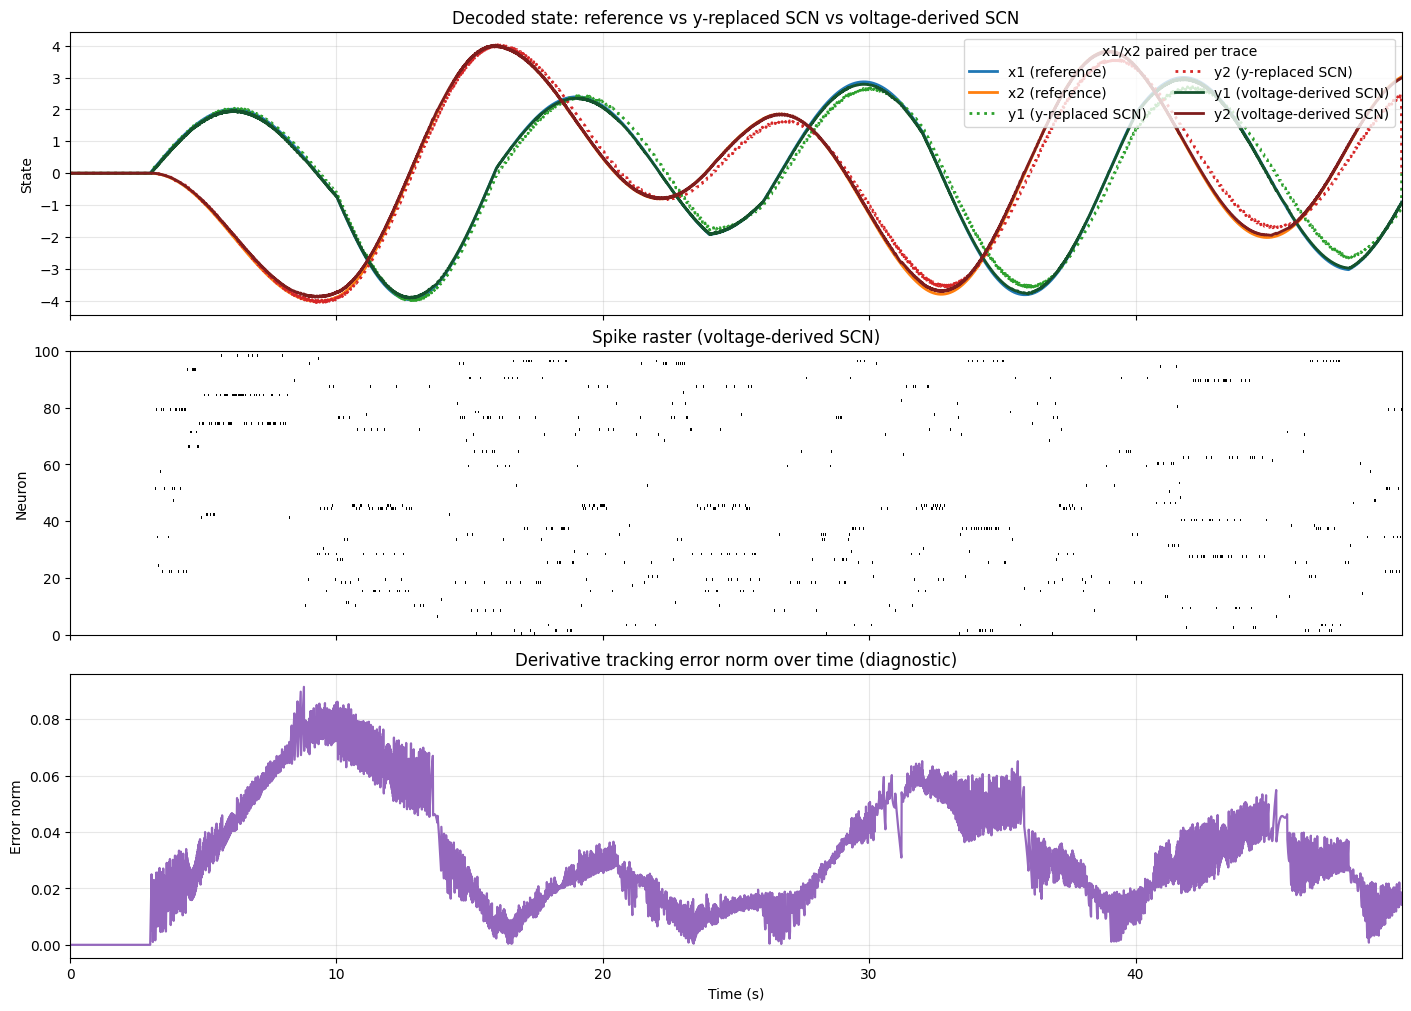

Mean derivative tracking error: 0.031215
Spike metrics:
  Total spikes: 2858
  Active neurons: 91/100 (91.0%)
  Silent neurons: 9/100 (9.0%)
  Mean firing rate per neuron: 0.572 Hz
  Mean population rate: 0.572 Hz/neuron
  Peak population rate: 1.000 Hz/neuron
  Top-5 neuron spike share: 25.9%


In [ ]:

# No explicit loss enumeration: use voltage from projected derivative mismatch
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed)
t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, slow_segments)
steps = len(t)

D = rng.normal(0, 1, size=(2, neurons))
D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale
E = D.T

s = np.zeros((steps, neurons))
r = np.zeros((steps, neurons))
r_s = np.zeros((steps, neurons))
y = np.zeros((steps, 2))
v = np.zeros((steps, neurons))
tracking_error_history = np.zeros(steps)

thresholds = 0.5 * np.diag(D.T @ D)

for i in range(steps - 1):
    # Target derivative from the reference system
    y_target = A @ x_ref[i] + (B[:, 0] * u[i])

    # Euler no-spike prediction for the slow filtered state
    r_dot_no_spike = -leak_r * r[i]
    r_s_dot_no_spike = lambda_slow * (-r_s[i] + r[i])
    y_actual = D @ r_s_dot_no_spike

    # Voltage from projected derivative mismatch, plus fast recurrent reset
    derivative_mismatch = y_target - y_actual
    v_dot = -voltage_leak * v[i] + D.T @ derivative_mismatch - D.T @ (D @ s[i])
    v[i + 1] = v[i] + dt * v_dot

    above_threshold = np.where(v[i + 1] > thresholds)[0]
    if len(above_threshold) > 0:
        winner_local = np.argmax(v[i + 1, above_threshold] - thresholds[above_threshold])
        winner = above_threshold[winner_local]
        s[i + 1, winner] = 1.0 / dt

    # filtered spikes update
    r[i + 1] = r[i] + dt * r_dot_no_spike + s[i + 1]

    # slow filtered r update
    r_s[i + 1] = r_s[i] + dt * r_s_dot_no_spike
    y[i + 1] = D @ r_s[i + 1]

    # Diagnostic only
    y_dot_actual = A @ y[i + 1] + B[:, 0] * u[i]
    tracking_error_history[i + 1] = np.linalg.norm(y_target - y_dot_actual)

# y-replaced SCN for comparison
t_yrep_cmp, u_yrep_cmp, x_ref_yrep_cmp, y_yrep_cmp, s_yrep_cmp, r_yrep_cmp = simulate_y_replaced_system(
    T, dt, speed, leak, slow_segments,
    neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

# Spike metrics
spike_events = s > 0
duration_s = t[-1] - t[0] + dt
total_spikes = int(np.count_nonzero(spike_events))
per_neuron_spikes = spike_events.sum(axis=0)
active_neurons = int(np.count_nonzero(per_neuron_spikes))
silent_neurons = neurons - active_neurons
mean_firing_rate_hz = total_spikes / (neurons * duration_s)
pop_rate_hz = spike_events.sum(axis=1) / (neurons * dt)
peak_pop_rate_hz = float(np.max(pop_rate_hz))
mean_pop_rate_hz = float(np.mean(pop_rate_hz))
top5_share = float(np.sum(np.sort(per_neuron_spikes)[-5:]) / max(1, total_spikes))

# Display-only smoothing of decoded trajectories
smooth_window = max(1, int(0.2 / dt))
kernel = np.ones(smooth_window) / smooth_window
y_smooth = np.column_stack([
    np.convolve(y[:, j], kernel, mode='same') for j in range(y.shape[1])
])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

analog_x1, = axes[0].plot(t, x_ref[:, 0], label='x1 (reference)', color='tab:blue', linewidth=2.0)
analog_x2, = axes[0].plot(t, x_ref[:, 1], label='x2 (reference)', color='tab:orange', linewidth=2.0)
recurrent_y1, = axes[0].plot(t_yrep_cmp, y_yrep_cmp[:, 0], ':', label='y1 (y-replaced SCN)', color='tab:green', linewidth=2.0)
recurrent_y2, = axes[0].plot(t_yrep_cmp, y_yrep_cmp[:, 1], ':', label='y2 (y-replaced SCN)', color='tab:red', linewidth=2.0)
voltage_y1, = axes[0].plot(t, y[:, 0], label='y1 (voltage-derived SCN)', color='#14532D', linewidth=2.0)
voltage_y2, = axes[0].plot(t, y[:, 1], label='y2 (voltage-derived SCN)', color='#7F1D1D', linewidth=2.0)
axes[0].set_title('Decoded state: reference vs y-replaced SCN vs voltage-derived SCN')
axes[0].set_ylabel('State')
axes[0].legend(
    handles=[analog_x1, analog_x2, recurrent_y1, recurrent_y2, voltage_y1, voltage_y2],
    loc='upper right',
    ncol=2,
    title='x1/x2 paired per trace',
)
axes[0].grid(True, alpha=0.3)

spike_image = (s > 0).T.astype(float)
axes[1].imshow(
    spike_image,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t[0], t[-1], 0, s.shape[1]],
    cmap='Greys',
)
axes[1].set_title('Spike raster (voltage-derived SCN)')
axes[1].set_ylabel('Neuron')

axes[2].plot(t, tracking_error_history, color='tab:purple', linewidth=1.6)
axes[2].set_title('Derivative tracking error norm over time (diagnostic)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Error norm')
axes[2].grid(True, alpha=0.3)

plt.show()

print(f'Mean derivative tracking error: {tracking_error_history.mean():.6f}')
print('Spike metrics:')
print(f'  Total spikes: {total_spikes}')
print(f'  Active neurons: {active_neurons}/{neurons} ({100.0 * active_neurons / neurons:.1f}%)')
print(f'  Silent neurons: {silent_neurons}/{neurons} ({100.0 * silent_neurons / neurons:.1f}%)')
print(f'  Mean firing rate per neuron: {mean_firing_rate_hz:.3f} Hz')
print(f'  Mean population rate: {mean_pop_rate_hz:.3f} Hz/neuron')
print(f'  Peak population rate: {peak_pop_rate_hz:.3f} Hz/neuron')
print(f'  Top-5 neuron spike share: {100.0 * top5_share:.1f}%')

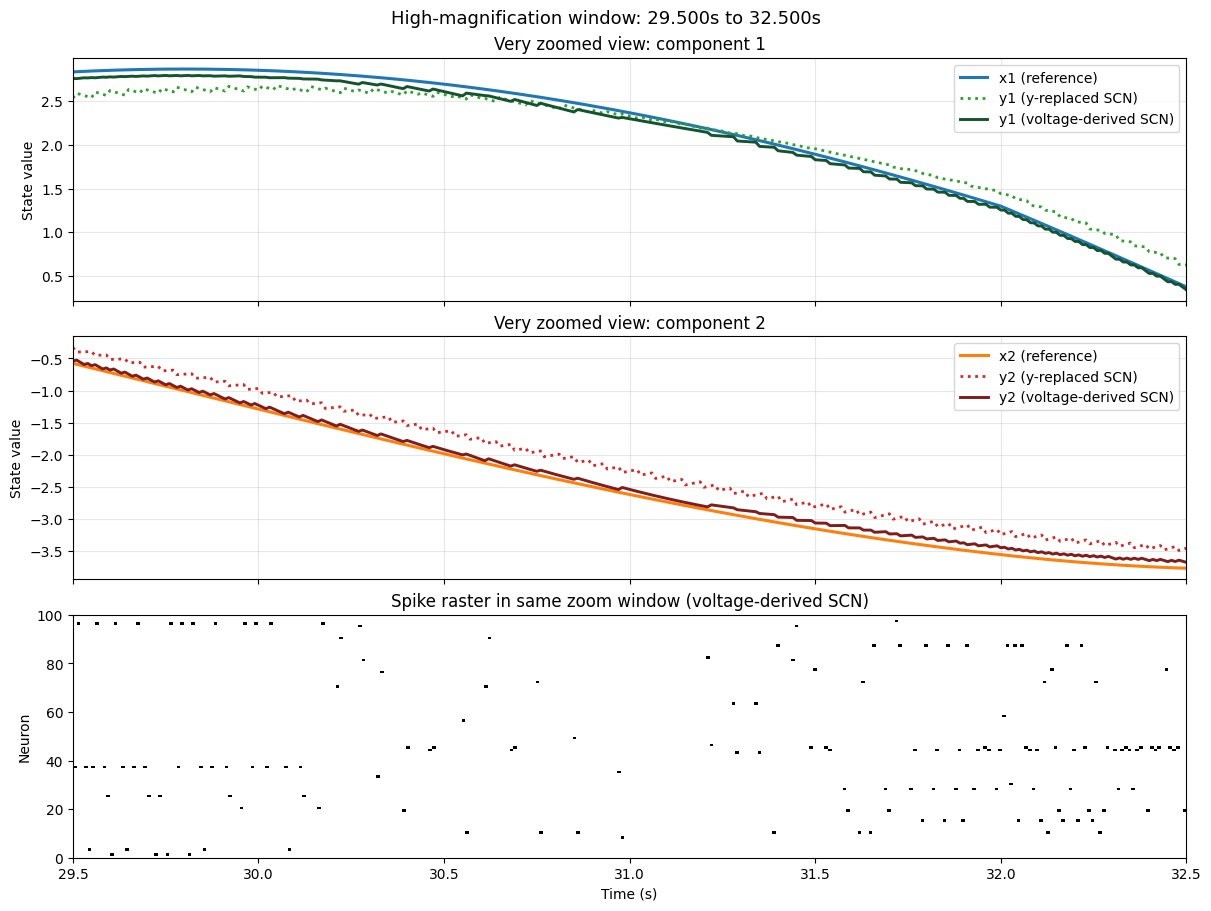

In [ ]:

# Zoomed-in trace view for the voltage-derived spike-rule model
zoom_center = 31.0   # seconds
zoom_width = 3.0     # seconds

t0 = max(t[0], zoom_center - zoom_width / 2)
t1 = min(t[-1], zoom_center + zoom_width / 2)
mask_main = (t >= t0) & (t <= t1)
mask_yrep = (t_yrep >= t0) & (t_yrep <= t1)

idx_main = np.where(mask_main)[0]
s_zoom = s[idx_main]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

# Component 1
axes[0].plot(t[mask_main], x_ref[mask_main, 0], color='tab:blue', linewidth=2.2, label='x1 (reference)')
axes[0].plot(t_yrep[mask_yrep], y_yrep[mask_yrep, 0], ':', color='tab:green', linewidth=2.0, label='y1 (y-replaced SCN)')
axes[0].plot(t[mask_main], y[mask_main, 0], color='#14532D', linewidth=2.1, label='y1 (voltage-derived SCN)')
axes[0].set_title('Very zoomed view: component 1')
axes[0].set_ylabel('State value')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

# Component 2
axes[1].plot(t[mask_main], x_ref[mask_main, 1], color='tab:orange', linewidth=2.2, label='x2 (reference)')
axes[1].plot(t_yrep[mask_yrep], y_yrep[mask_yrep, 1], ':', color='tab:red', linewidth=2.0, label='y2 (y-replaced SCN)')
axes[1].plot(t[mask_main], y[mask_main, 1], color='#7F1D1D', linewidth=2.1, label='y2 (voltage-derived SCN)')
axes[1].set_title('Very zoomed view: component 2')
axes[1].set_ylabel('State value')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

# Spike raster underneath
spike_image_zoom = (s_zoom > 0).T.astype(float)
axes[2].imshow(
    spike_image_zoom,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[t0, t1, 0, s.shape[1]],
    cmap='Greys',
)
axes[2].set_title('Spike raster in same zoom window (voltage-derived SCN)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Neuron')
axes[2].grid(False)

fig.suptitle(f'High-magnification window: {t0:.3f}s to {t1:.3f}s', fontsize=13)
plt.show()

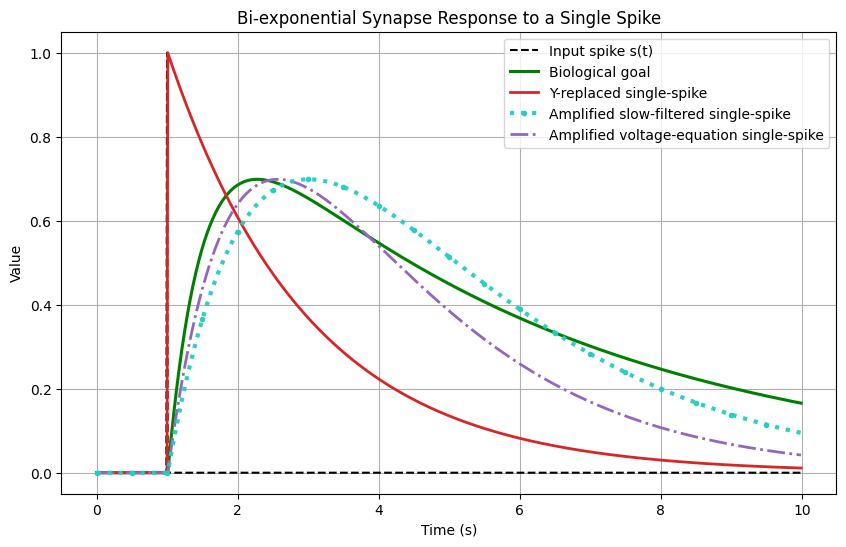

In [ ]:

plt.figure(figsize=(10, 6))
t_goal, s_goal, r_rise, r_decay, r_bi, r_s_model = simulate_bi_exponential_goal(
    total_time=10.0, dt=0.01, spike_at_time=1.0,
    leak_rise=2.0, leak_decay=0.2, leak_r_model=0.8, leak_r_s_model=0.2
)

# Single-spike response using the same fast synapse update as the y-replaced section.
r_yrep_single = np.zeros_like(t_goal)
r_slow_filtered_single = np.zeros_like(t_goal)

# Single-spike response using the newer voltage-equation-style cascade.
lambda_fast_voltage = 0.8
r_voltage_single = np.zeros_like(t_goal)
r_voltage_slow_single = np.zeros_like(t_goal)

for i in range(len(t_goal) - 1):
    r_yrep_single[i + 1] = r_yrep_single[i] + dt * (-leak_r * r_yrep_single[i] + s_goal[i] / dt)
    r_slow_filtered_single[i + 1] = r_slow_filtered_single[i] + dt * (lambda_slow * (-r_slow_filtered_single[i] + r_yrep_single[i]))
    r_voltage_single[i + 1] = r_voltage_single[i] + dt * (-lambda_fast_voltage * r_voltage_single[i] + s_goal[i] / dt)
    r_voltage_slow_single[i + 1] = r_voltage_slow_single[i] + dt * (lambda_slow * (-r_voltage_slow_single[i] + r_voltage_single[i]))

biological_peak = np.max(r_bi)

slow_filtered_peak = np.max(r_slow_filtered_single)
slow_filtered_amplified = r_slow_filtered_single.copy()
if slow_filtered_peak > 0:
    slow_filtered_amplified *= biological_peak / slow_filtered_peak

voltage_peak = np.max(r_voltage_slow_single)
voltage_amplified = r_voltage_slow_single.copy()
if voltage_peak > 0:
    voltage_amplified *= biological_peak / voltage_peak

plt.plot(t_goal, s_goal, label='Input spike s(t)', color='black', linestyle='--')
plt.plot(t_goal, r_bi, label='Biological goal', color='green', linewidth=2.2, zorder=2)
plt.plot(t_goal, r_yrep_single, label='Y-replaced single-spike', color='tab:red', linewidth=2.0, zorder=3)
plt.plot(
    t_goal,
    slow_filtered_amplified,
    label='Amplified slow-filtered single-spike',
    color="#21CEBF",
    linewidth=3.0,
    linestyle=':',
    marker='o',
    markevery=50,
    markersize=3,
    alpha=0.95,
    zorder=5,
)
plt.plot(
    t_goal,
    voltage_amplified,
    label='Amplified voltage-equation single-spike',
    color='tab:purple',
    linewidth=2.0,
    linestyle='-.',
    zorder=4,
)
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Bi-exponential Synapse Response to a Single Spike')
plt.legend()
plt.grid()
plt.show()

In [ ]:

from IPython.display import display, Markdown

display(Markdown(
    "### Metrics"
))

### Metrics

In [ ]:

# Consolidated research metrics: single-spike and state-trace comparisons
import numpy as np
from IPython.display import display, Markdown

display(Markdown(
    "### Consolidated Research Metrics\n"
    "- **Table 1** compares single-spike response traces against the biological goal.\n"
    "- **Table 2** compares decoded state traces against the analog reference state.\n"
    "- Shared metrics: RMSE, MAE, Corr, R2, Area Rel Err, and **Phase lag (s)** from cross-correlation.\n"
    "- For 2D state traces, metrics are averaged across x1/x2; phase lag is mean absolute lag across x1/x2."
))

def core_trace_metrics(ref, pred, t, dt):
    err = pred - ref
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))

    ref_std = float(np.std(ref))
    pred_std = float(np.std(pred))
    if ref_std > 1e-12 and pred_std > 1e-12:
        corr = float(np.corrcoef(ref, pred)[0, 1])
    else:
        corr = float('nan')

    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((ref - np.mean(ref)) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')

    area_ref = float(np.trapezoid(ref, t))
    area_pred = float(np.trapezoid(pred, t))
    area_rel_err_pct = 100.0 * abs(area_pred - area_ref) / (abs(area_ref) + 1e-12)

    # Signed lag: positive means pred lags ref in time.
    ref_centered = ref - np.mean(ref)
    pred_centered = pred - np.mean(pred)
    xcorr = np.correlate(pred_centered, ref_centered, mode='full')
    lag_idx = int(np.argmax(xcorr) - (len(ref) - 1))
    lag_s = lag_idx * dt

    return {
        'rmse': rmse,
        'mae': mae,
        'corr': corr,
        'r2': r2,
        'area_rel_err_pct': area_rel_err_pct,
        'phase_lag_s': lag_s,
    }

def spike_metrics(s):
    spikes = s > 0
    duration_s = s.shape[0] * dt
    total_spikes = int(np.count_nonzero(spikes))
    active_neurons = int(np.count_nonzero(spikes.sum(axis=0)))
    mean_firing_rate = total_spikes / (s.shape[1] * duration_s)
    pop_rate = spikes.sum(axis=1) / (s.shape[1] * dt)
    peak_pop_rate = float(np.max(pop_rate))
    return total_spikes, active_neurons, mean_firing_rate, peak_pop_rate

def simulate_voltage_derived_system_local(T, dt, speed, leak, input_segments, neurons=100, voltage_leak=0.5, seed=0):
    rng = np.random.default_rng(seed)
    t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, input_segments)
    steps = len(t)

    D = rng.normal(0, 1, size=(2, neurons))
    D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale

    s = np.zeros((steps, neurons))
    r = np.zeros((steps, neurons))
    r_s = np.zeros((steps, neurons))
    y = np.zeros((steps, 2))
    v = np.zeros((steps, neurons))
    thresholds = 0.5 * np.diag(D.T @ D)

    for i in range(steps - 1):
        y_target = A @ x_ref[i] + (B[:, 0] * u[i])
        r_dot_no_spike = -leak_r * r[i]
        r_s_dot_no_spike = lambda_slow * (-r_s[i] + r[i])
        y_actual = D @ r_s_dot_no_spike

        derivative_mismatch = y_target - y_actual
        v_dot = -voltage_leak * v[i] + D.T @ derivative_mismatch - D.T @ (D @ s[i])
        v[i + 1] = v[i] + dt * v_dot

        above = np.where(v[i + 1] > thresholds)[0]
        if len(above) > 0:
            winner_local = np.argmax(v[i + 1, above] - thresholds[above])
            winner = above[winner_local]
            s[i + 1, winner] = 1.0 / dt

        r[i + 1] = r[i] + dt * r_dot_no_spike + s[i + 1]
        r_s[i + 1] = r_s[i] + dt * r_s_dot_no_spike
        y[i + 1] = D @ r_s[i + 1]

    return t, u, x_ref, y, s, r_s

# -----------------------------
# Table 1: Single-spike traces
# -----------------------------
t_spk, s_spk, _, _, r_bio, _ = simulate_bi_exponential_goal(
    total_time=10.0, dt=dt, spike_at_time=1.0,
    leak_rise=2.0, leak_decay=0.2, leak_r_model=0.8, leak_r_s_model=0.2
)

r_yrep = np.zeros_like(t_spk)
r_slow = np.zeros_like(t_spk)
r_volt = np.zeros_like(t_spk)
r_volt_slow = np.zeros_like(t_spk)
lambda_fast_voltage_local = 0.8

for i in range(len(t_spk) - 1):
    r_yrep[i + 1] = r_yrep[i] + dt * (-leak_r * r_yrep[i] + s_spk[i] / dt)
    r_slow[i + 1] = r_slow[i] + dt * (lambda_slow * (-r_slow[i] + r_yrep[i]))
    r_volt[i + 1] = r_volt[i] + dt * (-lambda_fast_voltage_local * r_volt[i] + s_spk[i] / dt)
    r_volt_slow[i + 1] = r_volt_slow[i] + dt * (lambda_slow * (-r_volt_slow[i] + r_volt[i]))

# Match slow-filtered by area and voltage-derived by peak for a fair shape/timing comparison.
r_slow_scaled = r_slow.copy()
slow_area = float(np.trapezoid(r_slow, t_spk))
bio_area = float(np.trapezoid(r_bio, t_spk))
if slow_area > 0:
    r_slow_scaled *= bio_area / slow_area

r_volt_scaled = r_volt_slow.copy()
volt_peak = float(np.max(r_volt_slow))
bio_peak = float(np.max(r_bio))
if volt_peak > 0:
    r_volt_scaled *= bio_peak / volt_peak

single_spike_rows = [
    ('biological goal (self-reference)', r_bio),
    ('y-replaced SCN (single-spike)', r_yrep),
    ('slow-filtered SCN (single-spike)', r_slow_scaled),
    ('voltage-derived SCN (single-spike)', r_volt_scaled),
]

single_spike_metrics = []
for name, pred in single_spike_rows:
    m = core_trace_metrics(r_bio, pred, t_spk, dt)
    single_spike_metrics.append((name, m))

single_table = [
    '| Trace | RMSE | MAE | Corr | R2 | Area Rel Err (%) | Phase lag (s) |',
    '|:---|---:|---:|---:|---:|---:|---:|',
]
for name, m in sorted(single_spike_metrics, key=lambda x: x[1]['rmse']):
    single_table.append(
        f"| {name} | `{m['rmse']:.4f}` | `{m['mae']:.4f}` | `{m['corr']:.4f}` | `{m['r2']:.4f}` | `{m['area_rel_err_pct']:.2f}` | `{m['phase_lag_s']:.3f}` |"
    )

display(Markdown('### Table 1: Single-Spike Trace Fidelity (target: biological goal)'))
display(Markdown('\n'.join(single_table)))

# -----------------------------
# Table 2: State traces + spikes
# -----------------------------
t_base, u_base, x_base, y_base, s_base, r_base = simulate_scn_linear_system(
    T, dt, speed, leak, slow_segments, neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)
t_rec, u_rec, x_rec, y_rec, s_rec, r_rec = simulate_y_replaced_system(
    T, dt, speed, leak, slow_segments, neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)
t_slow, u_slow, x_slow, y_slow, y_slow_unfiltered, s_slow, r_slow = simulate_scn_linear_system_local(
    T, dt, speed, leak, slow_segments, neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)
t_volt, u_volt, x_volt, y_volt, s_volt, r_volt = simulate_voltage_derived_system_local(
    T, dt, speed, leak, slow_segments, neurons=neurons, voltage_leak=voltage_leak, seed=seed,
)

x_target = x_base
state_candidates = [
    ('baseline SCN (state trace)', y_base, s_base),
    ('y-replaced SCN (state trace)', y_rec, s_rec),
    ('slow-filtered SCN (state trace)', y_slow, s_slow),
    ('voltage-derived SCN (state trace)', y_volt, s_volt),
]

state_metrics = []
for name, y_pred, s_pred in state_candidates:
    m_x1 = core_trace_metrics(x_target[:, 0], y_pred[:, 0], t_base, dt)
    m_x2 = core_trace_metrics(x_target[:, 1], y_pred[:, 1], t_base, dt)
    state_metrics.append({
        'name': name,
        'rmse': 0.5 * (m_x1['rmse'] + m_x2['rmse']),
        'mae': 0.5 * (m_x1['mae'] + m_x2['mae']),
        'corr': 0.5 * (m_x1['corr'] + m_x2['corr']),
        'r2': 0.5 * (m_x1['r2'] + m_x2['r2']),
        'area_rel_err_pct': 0.5 * (m_x1['area_rel_err_pct'] + m_x2['area_rel_err_pct']),
        'phase_lag_s': 0.5 * (abs(m_x1['phase_lag_s']) + abs(m_x2['phase_lag_s'])),
        'spike': spike_metrics(s_pred),
    })

state_table = [
    '| Trace | RMSE | MAE | Corr | R2 | Area Rel Err (%) | Phase lag (s) |',
    '|:---|---:|---:|---:|---:|---:|---:|',
]
for row in sorted(state_metrics, key=lambda r: r['rmse']):
    state_table.append(
        f"| {row['name']} | `{row['rmse']:.4f}` | `{row['mae']:.4f}` | `{row['corr']:.4f}` | `{row['r2']:.4f}` | `{row['area_rel_err_pct']:.2f}` | `{row['phase_lag_s']:.3f}` |"
    )

display(Markdown('### Table 2: State-Trace Fidelity (target: analog reference x)'))
display(Markdown('\n'.join(state_table)))

spike_table = [
    '| Trace | Total spikes | Active neurons | Mean firing rate (Hz/neuron) | Peak population rate (Hz/neuron) |',
    '|:---|---:|---:|---:|---:|',
]
for row in state_metrics:
    total_spikes, active_neurons, mean_rate, peak_rate = row['spike']
    spike_table.append(
        f"| {row['name']} | `{total_spikes}` | `{active_neurons}/{neurons}` | `{mean_rate:.3f}` | `{peak_rate:.3f}` |"
    )

display(Markdown('### Spike-Activity Context (for Table 2 traces)'))
display(Markdown('\n'.join(spike_table)))

### Consolidated Research Metrics
- **Table 1** compares single-spike response traces against the biological goal.
- **Table 2** compares decoded state traces against the analog reference state.
- Shared metrics: RMSE, MAE, Corr, R2, Area Rel Err, and **Phase lag (s)** from cross-correlation.
- For 2D state traces, metrics are averaged across x1/x2; phase lag is mean absolute lag across x1/x2.

### Consolidated Research Metrics
- **Table 1** compares single-spike response traces against the biological goal.
- **Table 2** compares decoded state traces against the analog reference state.
- Shared metrics: RMSE, MAE, Corr, R2, Area Rel Err, and **Phase lag (s)** from cross-correlation.
- For 2D state traces, metrics are averaged across x1/x2; phase lag is mean absolute lag across x1/x2.

### Table 1: Single-Spike Trace Fidelity (target: biological goal)

| Trace | RMSE | MAE | Corr | R2 | Area Rel Err (%) | Phase lag (s) |
|:---|---:|---:|---:|---:|---:|---:|
| biological goal (self-reference) | `0.0000` | `0.0000` | `1.0000` | `1.0000` | `0.00` | `0.000` |
| slow-filtered SCN (single-spike) | `0.0701` | `0.0569` | `0.9584` | `0.8849` | `0.00` | `0.020` |
| voltage-derived SCN (single-spike) | `0.0925` | `0.0756` | `0.9725` | `0.7992` | `19.33` | `0.000` |
| y-replaced SCN (single-spike) | `0.2693` | `0.2339` | `0.5873` | `-0.7008` | `46.14` | `-0.440` |

### Consolidated Research Metrics
- **Table 1** compares single-spike response traces against the biological goal.
- **Table 2** compares decoded state traces against the analog reference state.
- Shared metrics: RMSE, MAE, Corr, R2, Area Rel Err, and **Phase lag (s)** from cross-correlation.
- For 2D state traces, metrics are averaged across x1/x2; phase lag is mean absolute lag across x1/x2.

### Table 1: Single-Spike Trace Fidelity (target: biological goal)

| Trace | RMSE | MAE | Corr | R2 | Area Rel Err (%) | Phase lag (s) |
|:---|---:|---:|---:|---:|---:|---:|
| biological goal (self-reference) | `0.0000` | `0.0000` | `1.0000` | `1.0000` | `0.00` | `0.000` |
| slow-filtered SCN (single-spike) | `0.0701` | `0.0569` | `0.9584` | `0.8849` | `0.00` | `0.020` |
| voltage-derived SCN (single-spike) | `0.0925` | `0.0756` | `0.9725` | `0.7992` | `19.33` | `0.000` |
| y-replaced SCN (single-spike) | `0.2693` | `0.2339` | `0.5873` | `-0.7008` | `46.14` | `-0.440` |

ValueError: not enough values to unpack (expected 7, got 6)

In [ ]:
# Parameter scout: explore SCN parameterizations from the baseline snapshot
from itertools import product
from IPython.display import display, Markdown

def simulate_voltage_derived_system_local(T, dt, speed, leak, input_segments, neurons=100, voltage_leak=0.5, seed=0):
    rng = np.random.default_rng(seed)
    t, u, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, input_segments)
    steps = len(t)

    D = rng.normal(0, 1, size=(2, neurons))
    D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale

    s = np.zeros((steps, neurons))
    r = np.zeros((steps, neurons))
    r_s = np.zeros((steps, neurons))
    y = np.zeros((steps, 2))
    v = np.zeros((steps, neurons))
    thresholds = 0.5 * np.diag(D.T @ D)

    for i in range(steps - 1):
        y_target = A @ x_ref[i] + (B[:, 0] * u[i])
        r_dot_no_spike = -leak_r * r[i]
        r_s_dot_no_spike = lambda_slow * (-r_s[i] + r[i])
        y_actual = D @ r_s_dot_no_spike

        derivative_mismatch = y_target - y_actual
        v_dot = -voltage_leak * v[i] + D.T @ derivative_mismatch - D.T @ (D @ s[i])
        v[i + 1] = v[i] + dt * v_dot

        above = np.where(v[i + 1] > thresholds)[0]
        if len(above) > 0:
            winner = above[np.argmax(v[i + 1, above] - thresholds[above])]
            s[i + 1, winner] = 1.0 / dt

        r[i + 1] = r[i] + dt * r_dot_no_spike + s[i + 1]
        r_s[i + 1] = r_s[i] + dt * r_s_dot_no_spike
        y[i + 1] = D @ r_s[i + 1]

    return t, u, x_ref, y, s, r_s

def state_core_metrics(x_ref, y_pred, s_pred, dt):
    def one_dim(a, b):
        err = b - a
        rmse = float(np.sqrt(np.mean(err ** 2)))
        corr = float(np.corrcoef(a, b)[0, 1]) if np.std(a) > 1e-12 and np.std(b) > 1e-12 else float('nan')
        a0 = a - np.mean(a)
        b0 = b - np.mean(b)
        xcorr = np.correlate(b0, a0, mode='full')
        lag_idx = int(np.argmax(xcorr) - (len(a) - 1))
        lag_s = lag_idx * dt
        return rmse, corr, lag_s

    rmse1, corr1, lag1 = one_dim(x_ref[:, 0], y_pred[:, 0])
    rmse2, corr2, lag2 = one_dim(x_ref[:, 1], y_pred[:, 1])
    rmse = 0.5 * (rmse1 + rmse2)
    corr = 0.5 * (corr1 + corr2)
    phase_lag = 0.5 * (abs(lag1) + abs(lag2))

    spikes = s_pred > 0
    total_spikes = int(np.count_nonzero(spikes))
    mean_rate = total_spikes / (s_pred.shape[0] * dt * s_pred.shape[1])
    return rmse, corr, phase_lag, total_spikes, mean_rate

def run_config_experiment(cfg):
    old_cfg = dict(ACTIVE_CONFIG)
    apply_config(cfg)
    try:
        t_b, u_b, x_b, y_b, s_b, r_b = simulate_scn_linear_system(T, dt, speed, leak, slow_segments, neurons, voltage_leak, seed)
        t_y, u_y, x_y, y_y, s_y, r_y = simulate_y_replaced_system(T, dt, speed, leak, slow_segments, neurons, voltage_leak, seed)
        t_s, u_s, x_s, y_s, y_s_unfiltered, s_s, r_s = simulate_scn_linear_system_local(T, dt, speed, leak, slow_segments, neurons, voltage_leak, seed)
        t_v, u_v, x_v, y_v, s_v, r_v = simulate_voltage_derived_system_local(T, dt, speed, leak, slow_segments, neurons, voltage_leak, seed)

        models = [
            ('baseline', y_b, s_b),
            ('y-replaced', y_y, s_y),
            ('slow-filtered', y_s, s_s),
            ('voltage-derived', y_v, s_v),
        ]

        rows = []
        for model_name, y_pred, s_pred in models:
            rmse, corr, phase_lag, spikes, mean_rate = state_core_metrics(x_b, y_pred, s_pred, dt)
            balanced = rmse + 0.35 * phase_lag + 0.02 * mean_rate
            rows.append({
                'model': model_name,
                'rmse': rmse,
                'corr': corr,
                'phase_lag_s': phase_lag,
                'spikes': spikes,
                'mean_rate': mean_rate,
                'balanced_score': balanced,
            })
        return rows
    finally:
        apply_config(old_cfg)

# Small but informative sweep around baseline.
baseline = dict(BASELINE_CONFIG)
grid = {
    'leak_r': [0.35, 0.5, 0.7],
    'lambda_slow': [0.35, 0.5, 0.7],
    'voltage_leak': [0.3, 0.5, 0.8],
    'decoder_scale': [8.0, 10.0, 14.0],
    'neurons': [80, 100, 140],
}

candidates = []
for leak_r_v, lambda_slow_v, voltage_leak_v, decoder_scale_v, neurons_v in product(
    grid['leak_r'], grid['lambda_slow'], grid['voltage_leak'], grid['decoder_scale'], grid['neurons']
):
    cfg = dict(baseline)
    cfg.update({
        'leak_r': leak_r_v,
        'lambda_slow': lambda_slow_v,
        'voltage_leak': voltage_leak_v,
        'decoder_scale': decoder_scale_v,
        'neurons': neurons_v,
    })
    exp_rows = run_config_experiment(cfg)
    for row in exp_rows:
        row.update({
            'cfg': cfg,
            'cfg_label': f"lr={leak_r_v}, ls={lambda_slow_v}, vl={voltage_leak_v}, ds={decoder_scale_v}, n={neurons_v}",
        })
        candidates.append(row)

# Best per objective.
best_accuracy = min(candidates, key=lambda r: r['rmse'])
stable_candidates = [r for r in candidates if r['corr'] >= 0.98 and r['phase_lag_s'] <= 0.05]
best_efficiency = min(stable_candidates, key=lambda r: r['spikes']) if stable_candidates else min(candidates, key=lambda r: r['spikes'])
best_balanced = min(candidates, key=lambda r: r['balanced_score'])

def row_to_md(r):
    return (
        f"| {r['model']} | {r['cfg_label']} | `{r['rmse']:.4f}` | `{r['corr']:.4f}` | "
        f"`{r['phase_lag_s']:.3f}` | `{r['spikes']}` | `{r['mean_rate']:.3f}` | `{r['balanced_score']:.4f}` |"
    )

table = [
    '| Objective winner | Model | Config | RMSE | Corr | Phase lag (s) | Total spikes | Mean rate | Balanced score |',
    '|:---|:---|:---|---:|---:|---:|---:|---:|---:|',
    f"| Best accuracy | {best_accuracy['model']} | {best_accuracy['cfg_label']} | `{best_accuracy['rmse']:.4f}` | `{best_accuracy['corr']:.4f}` | `{best_accuracy['phase_lag_s']:.3f}` | `{best_accuracy['spikes']}` | `{best_accuracy['mean_rate']:.3f}` | `{best_accuracy['balanced_score']:.4f}` |",
    f"| Best efficiency (under high fidelity) | {best_efficiency['model']} | {best_efficiency['cfg_label']} | `{best_efficiency['rmse']:.4f}` | `{best_efficiency['corr']:.4f}` | `{best_efficiency['phase_lag_s']:.3f}` | `{best_efficiency['spikes']}` | `{best_efficiency['mean_rate']:.3f}` | `{best_efficiency['balanced_score']:.4f}` |",
    f"| Best balanced | {best_balanced['model']} | {best_balanced['cfg_label']} | `{best_balanced['rmse']:.4f}` | `{best_balanced['corr']:.4f}` | `{best_balanced['phase_lag_s']:.3f}` | `{best_balanced['spikes']}` | `{best_balanced['mean_rate']:.3f}` | `{best_balanced['balanced_score']:.4f}` |",
]

display(Markdown('### SCN Parameter Scout (around baseline)'))
display(Markdown('\n'.join(table)))

display(Markdown(
    "**Conclusions (auto-scout):**\n"
    f"- Accuracy frontier is currently led by **{best_accuracy['model']}**.\n"
    f"- Spike-efficient high-fidelity option is **{best_efficiency['model']}**.\n"
    f"- Best compromise by composite score is **{best_balanced['model']}**.\n"
    "- Your original defaults are preserved in `BASELINE_CONFIG`; call `reset_to_baseline()` any time."
))

### SCN Parameter Scout (around baseline)

| Objective winner | Model | Config | RMSE | Corr | Phase lag (s) | Total spikes | Mean rate | Balanced score |
|:---|:---|:---|---:|---:|---:|---:|---:|---:|
| Best accuracy | voltage-derived | lr=0.35, ls=0.7, vl=0.3, ds=14.0, n=100 | `0.0371` | `1.0000` | `0.000` | `2947` | `0.589` | `0.0488` |
| Best efficiency (under high fidelity) | baseline | lr=0.35, ls=0.35, vl=0.5, ds=8.0, n=80 | `0.2027` | `0.9955` | `0.005` | `100` | `0.025` | `0.2049` |
| Best balanced | voltage-derived | lr=0.35, ls=0.7, vl=0.5, ds=14.0, n=140 | `0.0378` | `1.0000` | `0.000` | `2994` | `0.428` | `0.0464` |

**Conclusions (auto-scout):**
- Accuracy frontier is currently led by **voltage-derived**.
- Spike-efficient high-fidelity option is **baseline**.
- Best compromise by composite score is **voltage-derived**.
- Your original defaults are preserved in `BASELINE_CONFIG`; call `reset_to_baseline()` any time.

: 

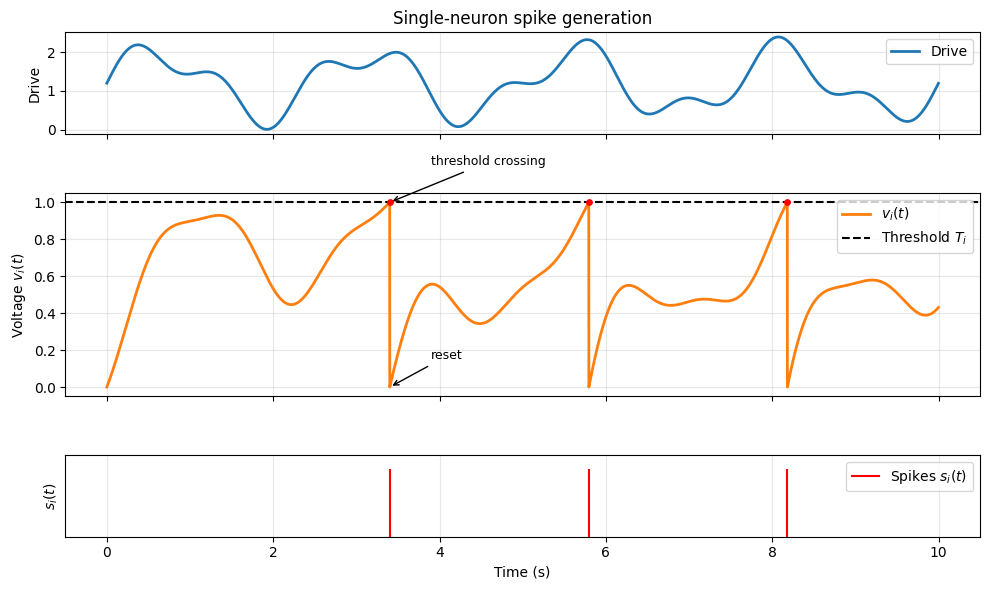

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
T = 10.0
dt = 0.001
t = np.arange(0, T, dt)

# Driving signal
drive = 1.2 + 0.8*np.sin(2*np.pi*0.4*t) + 0.4*np.sin(2*np.pi*0.9*t)
drive = np.clip(drive, 0, None)

# LIF parameters
lambda_v = 1.5
threshold = 1.0
v_reset = 0.0

# Simulate voltage
v = np.zeros_like(t)
spike_times = []
spike_indices = []

for i in range(1, len(t)):
    dv = -lambda_v * v[i-1] + drive[i-1]
    v[i] = v[i-1] + dt * dv

    if v[i] >= threshold:
        spike_times.append(t[i])
        spike_indices.append(i)
        v[i] = v_reset

# Plot
fig, axes = plt.subplots(
    3, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={"height_ratios": [1, 2, 0.8]}
)

# Panel 1: drive
axes[0].plot(t, drive, color="tab:blue", lw=2, label="Drive")
axes[0].set_ylabel("Drive")
axes[0].set_title("Single-neuron spike generation")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")

# Panel 2: voltage
axes[1].plot(t, v, color="tab:orange", lw=2, label=r"$v_i(t)$")
axes[1].axhline(threshold, color="black", ls="--", lw=1.5, label=r"Threshold $T_i$")
axes[1].scatter(spike_times, [threshold]*len(spike_times), color="red", s=15, zorder=5)
axes[1].set_ylabel(r"Voltage $v_i(t)$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

# Panel 3: spikes
axes[2].vlines(spike_times, 0, 1, color="red", lw=1.5)
axes[2].set_ylim(0, 1.2)
axes[2].set_ylabel(r"$s_i(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_yticks([])
axes[2].grid(True, alpha=0.3)

# Legend for red spike train
spike_handle = plt.Line2D([0], [0], color="red", lw=1.5, label=r"Spikes $s_i(t)$")
axes[2].legend(handles=[spike_handle], loc="upper right")

# Optional annotation
if len(spike_times) > 0:
    k = spike_indices[0]
    axes[1].annotate(
        "threshold crossing",
        xy=(t[k], threshold),
        xytext=(t[k] + 0.5, threshold + 0.2),
        arrowprops=dict(arrowstyle="->", lw=1),
        fontsize=9
    )
    axes[1].annotate(
        "reset",
        xy=(t[k], v_reset),
        xytext=(t[k] + 0.5, 0.15),
        arrowprops=dict(arrowstyle="->", lw=1),
        fontsize=9
    )

plt.tight_layout()
plt.savefig("single_neuron_spike_rule.png", dpi=300, bbox_inches="tight")
plt.show()

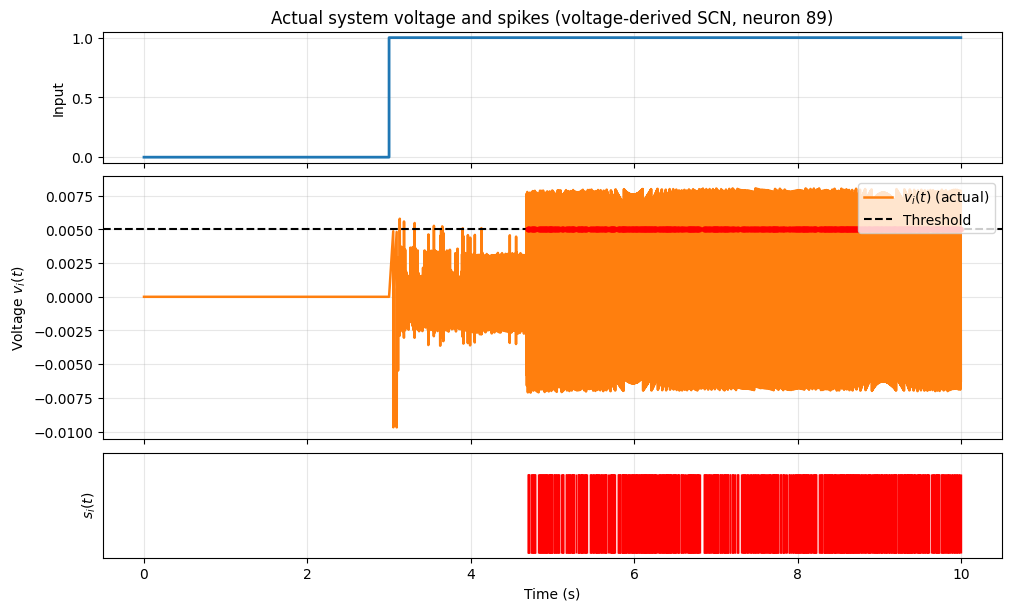

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Actual V from the voltage-derived SCN system (same dynamics used earlier in this notebook).
required_names = [
    "T", "dt", "speed", "leak", "slow_segments", "neurons",
    "voltage_leak", "seed", "decoder_scale", "leak_r", "lambda_slow",
    "simulate_linear_analog",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables/functions: {missing}. Run setup/simulation cells first.")

t_arr, u_arr, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, slow_segments)
steps = len(t_arr)
rng = np.random.default_rng(seed)

D = rng.normal(0, 1, size=(2, neurons))
D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale

s_arr = np.zeros((steps, neurons))
r_arr = np.zeros((steps, neurons))
r_s_arr = np.zeros((steps, neurons))
v_arr = np.zeros((steps, neurons))
thresholds_arr = 0.5 * np.diag(D.T @ D)

for i in range(steps - 1):
    y_target = A @ x_ref[i] + (B[:, 0] * u_arr[i])
    r_dot_no_spike = -leak_r * r_arr[i]
    r_s_dot_no_spike = lambda_slow * (-r_s_arr[i] + r_arr[i])
    y_actual = D @ r_s_dot_no_spike

    derivative_mismatch = y_target - y_actual
    v_dot = -voltage_leak * v_arr[i] + D.T @ derivative_mismatch - D.T @ (D @ s_arr[i])
    v_arr[i + 1] = v_arr[i] + dt * v_dot

    above = np.where(v_arr[i + 1] > thresholds_arr)[0]
    if len(above) > 0:
        winner = above[np.argmax(v_arr[i + 1, above] - thresholds_arr[above])]
        s_arr[i + 1, winner] = 1.0 / dt

    r_arr[i + 1] = r_arr[i] + dt * r_dot_no_spike + s_arr[i + 1]
    r_s_arr[i + 1] = r_s_arr[i] + dt * r_s_dot_no_spike

# Select a representative neuron (highest spike count).
spike_counts = (s_arr > 0).sum(axis=0)
neuron_idx = int(np.argmax(spike_counts))
v_trace = v_arr[:, neuron_idx]
threshold_value = float(thresholds_arr[neuron_idx])

spike_indices = np.where(s_arr[:, neuron_idx] > 0)[0]
spike_times = t_arr[spike_indices]

fig, axes = plt.subplots(
    3, 1, figsize=(10, 6), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2, 0.8]}
)

# Panel 1: actual system input
axes[0].step(t_arr, u_arr, where="post", color="tab:blue", lw=2)
axes[0].set_ylabel("Input")
axes[0].set_title(f"Actual system voltage and spikes (voltage-derived SCN, neuron {neuron_idx})")
axes[0].grid(True, alpha=0.3)

# Panel 2: actual system voltage
axes[1].plot(t_arr, v_trace, color="tab:orange", lw=1.8, label=r"$v_i(t)$ (actual)")
axes[1].axhline(threshold_value, color="black", ls="--", lw=1.5, label="Threshold")
if len(spike_times) > 0:
    axes[1].scatter(spike_times, [threshold_value] * len(spike_times), color="red", s=10, alpha=0.55, zorder=5)
axes[1].set_ylabel(r"Voltage $v_i(t)$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

# Panel 3: spike train
if len(spike_times) > 0:
    axes[2].eventplot(spike_times, lineoffsets=0.5, linelengths=0.9, colors="red", linewidths=1.0)
axes[2].set_ylim(0, 1.2)
axes[2].set_ylabel(r"$s_i(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_yticks([])
axes[2].grid(True, alpha=0.3)

plt.savefig("single_neuron_spike_rule_actualV.png", dpi=300, bbox_inches="tight")
plt.show()

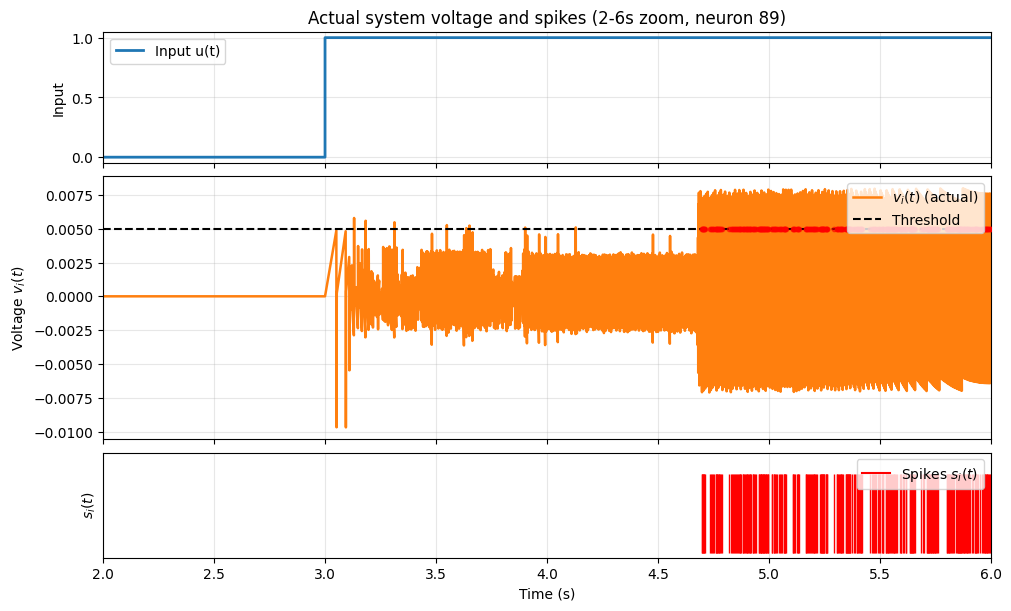

In [ ]:
# Zoomed view (2s to 6s) of the integrated actual-V plot
zoom_t0, zoom_t1 = 2.0, 6.0

# Reuse variables from Cell 31 if present; otherwise rebuild quickly.
if not all(name in globals() for name in ["t_arr", "u_arr", "v_trace", "threshold_value", "spike_times", "neuron_idx"]):
    t_arr, u_arr, x_ref, A, B = simulate_linear_analog(T, dt, speed, leak, slow_segments)
    steps = len(t_arr)
    rng = np.random.default_rng(seed)
    D = rng.normal(0, 1, size=(2, neurons))
    D = (D / np.linalg.norm(D, axis=0, keepdims=True)) / decoder_scale

    s_arr = np.zeros((steps, neurons))
    r_arr = np.zeros((steps, neurons))
    r_s_arr = np.zeros((steps, neurons))
    v_arr = np.zeros((steps, neurons))
    thresholds_arr = 0.5 * np.diag(D.T @ D)

    for i in range(steps - 1):
        y_target = A @ x_ref[i] + (B[:, 0] * u_arr[i])
        r_dot_no_spike = -leak_r * r_arr[i]
        r_s_dot_no_spike = lambda_slow * (-r_s_arr[i] + r_arr[i])
        y_actual = D @ r_s_dot_no_spike
        derivative_mismatch = y_target - y_actual
        v_dot = -voltage_leak * v_arr[i] + D.T @ derivative_mismatch - D.T @ (D @ s_arr[i])
        v_arr[i + 1] = v_arr[i] + dt * v_dot

        above = np.where(v_arr[i + 1] > thresholds_arr)[0]
        if len(above) > 0:
            winner = above[np.argmax(v_arr[i + 1, above] - thresholds_arr[above])]
            s_arr[i + 1, winner] = 1.0 / dt

        r_arr[i + 1] = r_arr[i] + dt * r_dot_no_spike + s_arr[i + 1]
        r_s_arr[i + 1] = r_s_arr[i] + dt * r_s_dot_no_spike

    spike_counts = (s_arr > 0).sum(axis=0)
    neuron_idx = int(np.argmax(spike_counts))
    v_trace = v_arr[:, neuron_idx]
    threshold_value = float(thresholds_arr[neuron_idx])
    spike_indices = np.where(s_arr[:, neuron_idx] > 0)[0]
    spike_times = t_arr[spike_indices]

mask_zoom = (t_arr >= zoom_t0) & (t_arr <= zoom_t1)
spike_times_zoom = np.asarray(spike_times)
spike_times_zoom = spike_times_zoom[(spike_times_zoom >= zoom_t0) & (spike_times_zoom <= zoom_t1)]

fig, axes = plt.subplots(
    3, 1, figsize=(10, 6), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2, 0.8]}
)

axes[0].step(
    t_arr[mask_zoom], u_arr[mask_zoom], where="post",
    color="tab:blue", lw=2, label="Input u(t)"
 )
axes[0].set_ylabel("Input")
axes[0].set_title(f"Actual system voltage and spikes (2-6s zoom, neuron {neuron_idx})")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

axes[1].plot(t_arr[mask_zoom], v_trace[mask_zoom], color="tab:orange", lw=1.8, label=r"$v_i(t)$ (actual)")
axes[1].axhline(threshold_value, color="black", ls="--", lw=1.5, label="Threshold")
if len(spike_times_zoom) > 0:
    axes[1].scatter(spike_times_zoom, [threshold_value] * len(spike_times_zoom), color="red", s=10, alpha=0.55, zorder=5)
axes[1].set_ylabel(r"Voltage $v_i(t)$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

if len(spike_times_zoom) > 0:
    axes[2].eventplot(spike_times_zoom, lineoffsets=0.5, linelengths=0.9, colors="red", linewidths=1.0)
axes[2].set_ylim(0, 1.2)
axes[2].set_ylabel(r"$s_i(t)$")
axes[2].set_xlabel("Time (s)")
axes[2].set_yticks([])
axes[2].grid(True, alpha=0.3)

# Legend for spike train (red)
spike_handle = plt.Line2D([0], [0], color="red", lw=1.5, label=r"Spikes $s_i(t)$")
axes[2].legend(handles=[spike_handle], loc="upper right")

for ax in axes:
    ax.set_xlim(zoom_t0, zoom_t1)

plt.savefig("single_neuron_spike_rule_actualV_zoom2_6.png", dpi=300, bbox_inches="tight")
plt.show()

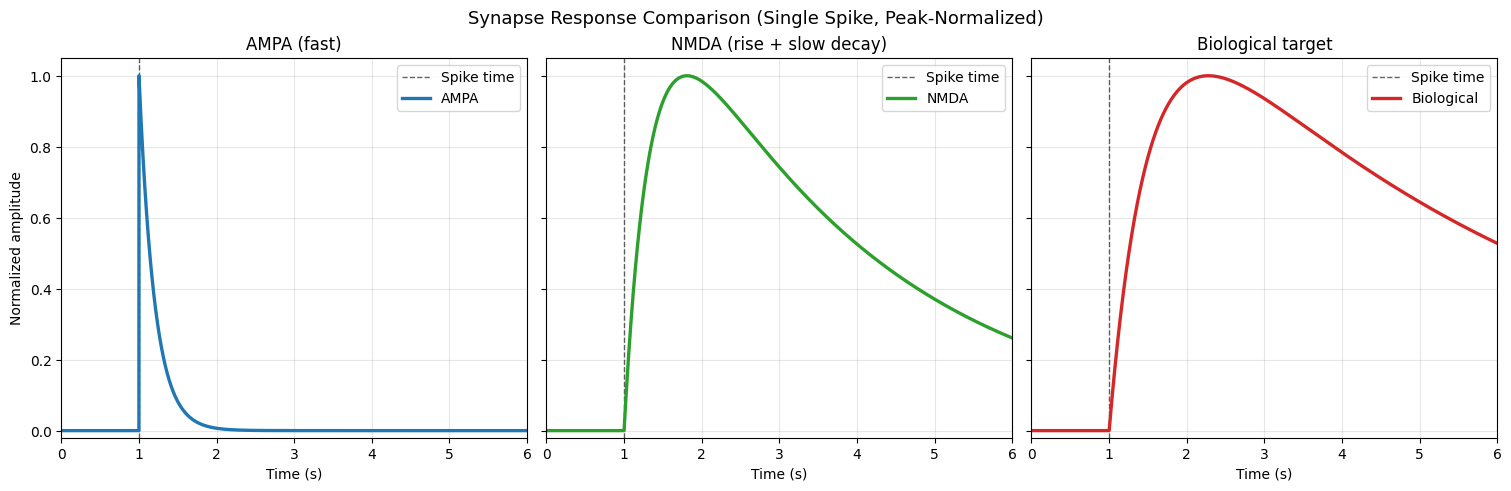

In [ ]:
# Side-by-side comparison: AMPA vs NMDA vs biological synapse response (fixed shapes)
import numpy as np
import matplotlib.pyplot as plt

dt_local = float(dt) if "dt" in globals() else 0.01
t_end = 8.0
t_syn = np.arange(0.0, t_end, dt_local)
spike_at_time = 1.0

# Single impulse with unit area
s_in = np.zeros_like(t_syn)
spike_idx = int(np.argmin(np.abs(t_syn - spike_at_time)))
s_in[spike_idx] = 1.0 / dt_local

def simulate_single_exp(spike_train, dt_step, leak_rate):
    trace = np.zeros_like(spike_train)
    for k in range(len(spike_train) - 1):
        trace[k + 1] = trace[k] + dt_step * (-leak_rate * trace[k] + spike_train[k])
    return trace

def simulate_bi_exp(spike_train, dt_step, leak_rise, leak_decay):
    rise = np.zeros_like(spike_train)
    decay = np.zeros_like(spike_train)
    for k in range(len(spike_train) - 1):
        rise[k + 1] = rise[k] + dt_step * (-leak_rise * rise[k] + spike_train[k])
        decay[k + 1] = decay[k] + dt_step * (-leak_decay * decay[k] + spike_train[k])
    out = decay - rise
    out[out < 0.0] = 0.0
    return out

# AMPA: fast first-order decay
lambda_ampa = 5.0
r_ampa = simulate_single_exp(s_in, dt_local, lambda_ampa)

# NMDA: bi-exponential (finite rise + slow decay)
lambda_nmda_rise = 3.0
lambda_nmda_decay = 0.35
r_nmda = simulate_bi_exp(s_in, dt_local, lambda_nmda_rise, lambda_nmda_decay)

# Biological target (prefer notebook helper if available)
if "simulate_bi_exponential_goal" in globals():
    t_bio, _, _, _, r_bio, _ = simulate_bi_exponential_goal(
        total_time=t_end,
        dt=dt_local,
        spike_at_time=spike_at_time,
        leak_rise=2.0,
        leak_decay=0.2,
        leak_r_model=0.8,
        leak_r_s_model=0.2,
    )
    if len(t_bio) != len(t_syn) or np.max(np.abs(t_bio - t_syn)) > 1e-12:
        r_bio = np.interp(t_syn, t_bio, r_bio)
else:
    r_bio = simulate_bi_exp(s_in, dt_local, leak_rise=2.0, leak_decay=0.2)

# Normalize to unit peak for shape-only comparison
def normalize_peak(arr):
    peak = float(np.max(np.abs(arr)))
    return arr / peak if peak > 0 else arr

r_ampa_n = normalize_peak(r_ampa)
r_nmda_n = normalize_peak(r_nmda)
r_bio_n = normalize_peak(r_bio)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True, constrained_layout=True)

for ax in axes:
    ax.axvline(spike_at_time, color="black", linestyle="--", linewidth=1.0, alpha=0.6, label="Spike time")
    ax.set_xlim(0.0, 6.0)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

axes[0].plot(t_syn, r_ampa_n, color="#1f77b4", linewidth=2.4, label="AMPA")
axes[0].set_title("AMPA (fast)")
axes[0].set_ylabel("Normalized amplitude")
axes[0].legend(loc="upper right")

axes[1].plot(t_syn, r_nmda_n, color="#2ca02c", linewidth=2.4, label="NMDA")
axes[1].set_title("NMDA (rise + slow decay)")
axes[1].legend(loc="upper right")

axes[2].plot(t_syn, r_bio_n, color="#d62728", linewidth=2.4, label="Biological")
axes[2].set_title("Biological target")
axes[2].legend(loc="upper right")

fig.suptitle("Synapse Response Comparison (Single Spike, Peak-Normalized)", fontsize=13)
plt.show()

In [18]:
# Spikes -> decoded state estimate (integrated naming, no filtered-activity panel)
import numpy as np
import matplotlib.pyplot as plt

if "simulate_scn_linear_system" not in globals():
    raise RuntimeError("Run the SCN setup cells first (simulate_scn_linear_system is missing).")

# Use baseline config when available to avoid mismatched lengths from temporary T/dt edits.
cfg = dict(BASELINE_CONFIG) if "BASELINE_CONFIG" in globals() else {
    "T": T,
    "dt": dt,
    "speed": speed,
    "leak": leak,
    "slow_segments": slow_segments,
    "neurons": neurons,
    "voltage_leak": voltage_leak,
    "seed": seed,
}

t_pipe, u_pipe, x_ref_pipe, y_pipe, s_pipe, _ = simulate_scn_linear_system(
    cfg["T"], cfg["dt"], cfg["speed"], cfg["leak"], cfg["slow_segments"],
    neurons=cfg["neurons"], voltage_leak=cfg["voltage_leak"], seed=cfg["seed"],
)

# Focus window for the explanatory pipeline figure
t0, t1 = 10.0, 20.0
mask = (t_pipe >= t0) & (t_pipe <= t1)

t_plot = t_pipe[mask]
x_ref_plot = x_ref_pipe[mask]
s_plot = s_pipe[mask]
y_plot = y_pipe[mask]

fig, axes = plt.subplots(
    3, 1, figsize=(11, 7), sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1.0, 1.2]}
)


axes[0].set_title("From spikes to decoded state estimate")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Panel 2: spike raster (first 15 neurons, or fewer if needed)
n_show = min(15, s_plot.shape[1])
selected_neurons = np.arange(n_show)
spike_times_list = [t_plot[s_plot[:, i] > 0] for i in selected_neurons]
axes[1].eventplot(spike_times_list, colors="black", lineoffsets=np.arange(n_show))
axes[1].set_ylabel("Neuron")
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3)

# Panel 3: decoded estimate y against reference x
axes[0].plot(t_plot, x_ref_plot[:, 0], "--", color="tab:blue", alpha=0.6, label=r"$x_1$ (reference)")
axes[0].plot(t_plot, y_plot[:, 0], color="tab:blue", lw=2, label=r"$y_1$ (decoded)")
axes[0].plot(t_plot, x_ref_plot[:, 1], "--", color="tab:orange", alpha=0.6, label=r"$x_2$ (reference)")
axes[0].plot(t_plot, y_plot[:, 1], color="tab:orange", lw=2, label=r"$y_2$ (decoded)")
axes[0].set_ylabel("Decoded\nstate")
axes[0].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("spikes_decode_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()

RuntimeError: Run the SCN setup cells first (simulate_scn_linear_system is missing).